# scProto + cell-cell similarity reconstruction (`lambda_sim_recon`) — train & eval

Self-contained notebook for one experiment: does adding the cell-cell
similarity reconstruction loss close the resolution gap between scProto and
SEACells? Background: SEACells' archetypal analysis reconstructs each cell's
full row of the affinity matrix (forcing archetypes to resolve genuine
per-cell heterogeneity); scProto's existing losses (nassoc, proto_usage)
only ever see a K×K summary, so a large, internally well-connected but
heterogeneous prototype pays no penalty. `lambda_sim_recon` (off by default,
see `configs/defaults.py`) adds that missing cell-level pressure: it decodes
each prototype into a predicted target and reconstructs it through `S`, with
both `S` and the prototypes kept trainable through this loss specifically
(see `scproto.py`'s `sim_recon_loss` block for the full reasoning on why
that differs from `proto_recon_loss`'s detached `S`).

Two target modes, both trained and compared here (`sim_recon_target`):
- **`full`** — reconstruct each cell's actual row of the affinity graph.
  Most literal match to what SEACells' RSS objective does.
- **`diffusion`** — regress to a small precomputed per-cell diffusion-map
  coordinate instead of the full row. Cheaper (no O(n_cells) decoder
  output), but the compression could in principle discard some of the
  resolving signal the `full` target has — that's an open question, not
  an assumption, which is why both get trained and compared side by side
  rather than picking one up front.

**Scope for this pass: BANKSY only.** BANKSY was the affinity that already
showed the highest niche purity in earlier affinity-comparison work, and is
the highest-value place to first find out whether either sim-recon target
actually closes the gap with SEACells — testing all three main affinities
up front is 6–9 scProto runs, too much before knowing the mechanism helps at
all. This trains exactly 3 scProto configs (BANKSY baseline, +full,
+diffusion) plus SEACells. A ready-to-uncomment section at the bottom
extends the same pattern to `arbf` / `mean_product` once BANKSY results
justify the extra Colab time.

Runs are matched for evaluation by **exact** saved model directory name
(captured right after training/loading), not by keyword substring — a
baseline run's name is always a literal substring of both its sim-recon
counterparts' names, so fuzzy keyword matching (as used in
`scproto_spatial_comparison.ipynb`, safe there because it only ever had one
variant per affinity) would silently match the wrong run. Exact-name
matching sidesteps that entirely.

## Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q scarches SEACells faiss-gpu-cu12 scib-metrics

In [ ]:
%run /content/drive/MyDrive/codes/interpretable-prototype/notebooks/nb_setup.py

nb_setup done. Available: get_trainer, run_mc_task, fig_*, LAMBDA_PROTO_UMAP, LAMBDA_PROTO_UMAP_PRECON, LAMBDA_PARAM_UMAP, LAMBDA_RECON_ONLY, train_sure, eval_sure_task1/2/3
Configs: {'LAMBDA_PROTO_UMAP': {'lambda_umap': 1, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 0, 'lambda_proto_recon': 0.0, 'umap_similarity': 'proto'}, 'LAMBDA_PARAM_UMAP': {'lambda_umap': 1, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 0, 'lambda_proto_recon': 0.0, 'umap_similarity': 'embedding'}, 'LAMBDA_RECON_ONLY': {'lambda_umap': 0, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 1, 'lambda_proto_recon': 0.0}}


## Config

In [ ]:
from interpretable_ssl.experiments.tasks import run_mc_task, LAMBDA_PROTO_UMAP_PRECON
from interpretable_ssl.evaluation.spatial_immune_task import NSCLC_EVAL_GROUPS
import pandas as pd

DS_ID = 's28nsc'
AFFINITY = 'banksy0.5'

# lambda_sim_recon=1.0 is a first guess — affinity values already live in
# ~[0,1], comparable scale to nassoc's own terms. Tune from here if purity
# doesn't move, or moves too aggressively at the cost of the other losses.
LAMBDA_SIM_RECON = 1.0
SIM_RECON_N_EIGS = 10  # only used by sim_recon_target='diffusion'

COMMON_KWARGS = dict(
    cvae_epochs=50,
    train_epochs=50,
    eval_freq=3,
    patience=6,
    batch_size=1024,
    umap_steps_per_epoch=500,
    niche_key='niches_2D',
    target_groups=NSCLC_EVAL_GROUPS,
    lambda_config=LAMBDA_PROTO_UMAP_PRECON | {'nassoc_agg': 'max'},
)

# Baseline: set True if you already trained banksy0.5 in
# train_scproto_spatial.ipynb and just want to reload that checkpoint here.
# Set False to train it fresh in this notebook (fully self-contained, just slower).
LOAD_BASELINE = True

# The sim-recon runs (both targets) are the new thing this notebook exists to
# produce — False trains them; flip to True on a re-run to just reload.
LOAD_SIMRECON = False

trainers = {}
results = {}
mc_adatas = {}
model_names = {}  # label -> exact saved model directory name (see note above on why exact, not keyword)


def train_or_load(label, affinity_type, load, extra_lambda=None):
    """Run (or reload) one scProto config and record its exact model directory name."""
    kwargs = COMMON_KWARGS if not extra_lambda else COMMON_KWARGS | {
        'lambda_config': COMMON_KWARGS['lambda_config'] | extra_lambda
    }
    t, res, mc_ad = run_mc_task(DS_ID, affinity_type=affinity_type, load_umap=load, **kwargs)
    trainers[label], results[label], mc_adatas[label] = t, res, mc_ad
    model_names[label] = t.get_model_name()
    print(f'{label}: {res}')
    return t, res, mc_ad

## Train / load — BANKSY, three configs

Each cell is independent — skip/re-run any one without affecting the others.

### Baseline (no sim-recon)

In [ ]:
train_or_load('banksy0.5', AFFINITY, load=LOAD_BASELINE)

 captum (see https://github.com/pytorch/captum).


dataset is None, loading s28nsc
loading s28nsc data
⚠️ No HVG column found.
proto_umap_ds-s28n_NP800_prtInit-wayp_aff-bank_lprec0.01_usim-prot_cvae_e50_ecal1_lpu0.1_pum-ema_lna1_nagg-max_upm-dotp_v31
Embedding dictionary:
 	Num conditions: [1]
 	Embedding dim: [10]
Encoder Architecture:
	Input Layer in, out and cond: 960 31 10
	Mean/Var Layer in/out: 31 8
Decoder Architecture:
	First Layer in, out and cond:  8 31 10
	Output Layer in/out:  31 960 

📊 Affinity: wdeg[min/mean/max]=12.393/17.964/21.988, effk_med=49.7, mutual=50.47%
adam
Loaded pretrain checkpoint from /content/drive/MyDrive/models/s28nsc/pretrain/pretrain_ds-s28nsc_cvae_e50/pretrain_checkpoint.pth
  pretrain_params: {'dataset_id': 's28nsc', 'cvae_epochs': 50, 'batch_size': 1024, 'latent_dims': 8, 'l2norm': 1, 'model_type': 'gm', 'beta': 0.3, 'condition_key': 'section'}
[waypoint init] N=58423  K=800  n_eigs=10  nnz=4367898  nnz/row=74.8  w[min/mean/max]=7.470e-02/2.403e-01/8.623e-01  deg[min/mean/max]=6.58/17.96/111.97
[wa

waypoint MaxMin: 100%|██████████| 799/799 [00:00<00:00, 969.57proto/s]


[waypoint init] selected 800 seed cells


  0%|          | 0/1 [00:00<?, ?it/s]

...

Saved metacells (800 prototypes) to /content/drive/MyDrive/models//s28nsc/proto_umap_ds-s28n_NP800_prtInit-wayp_aff-bank_lprec0.01_usim-prot_cvae_e50_ecal1_lpu0.1_pum-ema_lna1_nagg-max_upm-dotp_v31/metacells.h5ad


  0%|          | 0/49 [00:00<?, ?it/s]

  0%|          | 0/58 [00:00<?, ?it/s]

UMAP data saved to /content/drive/MyDrive/models//s28nsc/proto_umap_ds-s28n_NP800_prtInit-wayp_aff-bank_lprec0.01_usim-prot_cvae_e50_ecal1_lpu0.1_pum-ema_lna1_nagg-max_upm-dotp_v31
banksy0.5: {'purity': 0.9454848346328236, 'niche_purity': 0.9556897984987566, 'batch_entropy': -1.000000082690371e-10, 'modularity': 0.6323644658515475, 'coverage': 0.7222222222222222, 'dge_rbo_avg': 0.07852126083832636, 'dge_kendall_avg': 0.22059311644343244, 'dge_jaccard_avg': 0.07217606968953304, 'scgraph_corr_avg': 0.7911918845207447, 'ct_niche_rbo_avg': 0.011798300780381292, 'aff_compactness_per_batch': {'section_28': 16.082431193375523}, 'aff_compactness_mean': 10.32309958344581, 'tumor_cells_tumor_surface_purity': 0.313136442428438, 'tumor_cells_tumor_surface_coverage': 0.002916998143728454, 'tumor_cells_tumor_surface_homogeneity': 0.3715194908512331, 'tumor_cells_tumor_core_purity': 0.435596462251087, 'tumor_cells_tumor_core_coverage': 0.9655887230514096, 'tumor_cells_tumor_core_homogeneity': 0.42620

(<interpretable_ssl.trainers.scproto.SCProtoTrainer at 0x77fdb451d910>,
 {'purity': 0.9454848346328236,
  'niche_purity': 0.9556897984987566,
  'batch_entropy': -1.000000082690371e-10,
  'modularity': 0.6323644658515475,
  'coverage': 0.7222222222222222,
  'dge_rbo_avg': 0.07852126083832636,
  'dge_kendall_avg': 0.22059311644343244,
  'dge_jaccard_avg': 0.07217606968953304,
  'scgraph_corr_avg': 0.7911918845207447,
  'ct_niche_rbo_avg': 0.011798300780381292,
  'aff_compactness_per_batch': {'section_28': 16.082431193375523},
  'aff_compactness_mean': 10.32309958344581,
  'tumor_cells_tumor_surface_purity': 0.313136442428438,
  'tumor_cells_tumor_surface_coverage': 0.002916998143728454,
  'tumor_cells_tumor_surface_homogeneity': 0.3715194908512331,
  'tumor_cells_tumor_core_purity': 0.435596462251087,
  'tumor_cells_tumor_core_coverage': 0.9655887230514096,
  'tumor_cells_tumor_core_homogeneity': 0.4262023217247098,
  'tumor_cells_dc_islands_purity': 0.010480473116905926,
  'tumor_cells_

### +sim-recon (`full` target)

Everything else identical to the baseline above — a clean single-variable
ablation. Reconstructs each cell's actual affinity-graph row.

In [ ]:
train_or_load('banksy0.5+full', AFFINITY, load=LOAD_SIMRECON,
               extra_lambda={'lambda_sim_recon': LAMBDA_SIM_RECON, 'sim_recon_target': 'full'})

dataset is None, loading s28nsc
loading s28nsc data
⚠️ No HVG column found.
proto_umap_ds-s28n_NP800_prtInit-wayp_aff-bank_lprec0.01_usim-prot_cvae_e50_ecal1_lpu0.1_pum-ema_lna1_nagg-max_lsr1.0_upm-dotp_v31
Embedding dictionary:
 	Num conditions: [1]
 	Embedding dim: [10]
Encoder Architecture:
	Input Layer in, out and cond: 960 31 10
	Mean/Var Layer in/out: 31 8
Decoder Architecture:
	First Layer in, out and cond:  8 31 10
	Output Layer in/out:  31 960 

📊 Affinity: wdeg[min/mean/max]=12.393/17.964/21.988, effk_med=49.7, mutual=50.47%
adam
Loaded pretrain checkpoint from /content/drive/MyDrive/models/s28nsc/pretrain/pretrain_ds-s28nsc_cvae_e50/pretrain_checkpoint.pth
  pretrain_params: {'dataset_id': 's28nsc', 'cvae_epochs': 50, 'batch_size': 1024, 'latent_dims': 8, 'l2norm': 1, 'model_type': 'gm', 'beta': 0.3, 'condition_key': 'section'}
[waypoint init] N=58423  K=800  n_eigs=10  nnz=4367898  nnz/row=74.8  w[min/mean/max]=7.470e-02/2.403e-01/8.623e-01  deg[min/mean/max]=6.58/17.96/111

waypoint MaxMin: 100%|██████████| 799/799 [00:00<00:00, 893.15proto/s]


[waypoint init] selected 800 seed cells


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/58 [00:00<?, ?it/s]

...

Saved metacells (800 prototypes) to /content/drive/MyDrive/models//s28nsc/proto_umap_ds-s28n_NP800_prtInit-wayp_aff-bank_lprec0.01_usim-prot_cvae_e50_ecal1_lpu0.1_pum-ema_lna1_nagg-max_lsr1.0_upm-dotp_v31/metacells.h5ad


  0%|          | 0/49 [00:00<?, ?it/s]

  0%|          | 0/58 [00:00<?, ?it/s]

UMAP data saved to /content/drive/MyDrive/models//s28nsc/proto_umap_ds-s28n_NP800_prtInit-wayp_aff-bank_lprec0.01_usim-prot_cvae_e50_ecal1_lpu0.1_pum-ema_lna1_nagg-max_lsr1.0_upm-dotp_v31
banksy0.5+full: {'purity': 0.954900645449405, 'niche_purity': 0.9387789275626338, 'batch_entropy': -1.0000000826903709e-10, 'modularity': 0.6260482508372454, 'coverage': 0.8333333333333334, 'dge_rbo_avg': 0.2702243498334592, 'dge_kendall_avg': 0.2638846405134945, 'dge_jaccard_avg': 0.13519986417255012, 'scgraph_corr_avg': 0.7757028015291743, 'ct_niche_rbo_avg': 0.025042265870345703, 'aff_compactness_per_batch': {'section_28': 65.49747429528841}, 'aff_compactness_mean': 23.62431089738647, 'tumor_cells_tumor_surface_purity': 0.3126444751471386, 'tumor_cells_tumor_surface_coverage': 0.00477326968973747, 'tumor_cells_tumor_surface_homogeneity': 0.3794749403341289, 'tumor_cells_tumor_core_purity': 0.42675990522269164, 'tumor_cells_tumor_core_coverage': 0.9703565505804311, 'tumor_cells_tumor_core_homogeneit

(<interpretable_ssl.trainers.scproto.SCProtoTrainer at 0x77fd4a09eb40>,
 {'purity': 0.954900645449405,
  'niche_purity': 0.9387789275626338,
  'batch_entropy': -1.0000000826903709e-10,
  'modularity': 0.6260482508372454,
  'coverage': 0.8333333333333334,
  'dge_rbo_avg': 0.2702243498334592,
  'dge_kendall_avg': 0.2638846405134945,
  'dge_jaccard_avg': 0.13519986417255012,
  'scgraph_corr_avg': 0.7757028015291743,
  'ct_niche_rbo_avg': 0.025042265870345703,
  'aff_compactness_per_batch': {'section_28': 65.49747429528841},
  'aff_compactness_mean': 23.62431089738647,
  'tumor_cells_tumor_surface_purity': 0.3126444751471386,
  'tumor_cells_tumor_surface_coverage': 0.00477326968973747,
  'tumor_cells_tumor_surface_homogeneity': 0.3794749403341289,
  'tumor_cells_tumor_core_purity': 0.42675990522269164,
  'tumor_cells_tumor_core_coverage': 0.9703565505804311,
  'tumor_cells_tumor_core_homogeneity': 0.4114842454394693,
  'tumor_cells_dc_islands_purity': 0.010944591793236404,
  'tumor_cells_d

### +sim-recon (`diffusion` target)

Same ablation, but regresses to a precomputed `SIM_RECON_N_EIGS`-dim
diffusion-map coordinate per cell instead of the full affinity row —
cheaper, and the question this notebook exists to answer is whether that
compression costs any of the resolution benefit the `full` target gives.

In [ ]:
train_or_load('banksy0.5+diffusion', AFFINITY, load=LOAD_SIMRECON,
               extra_lambda={'lambda_sim_recon': LAMBDA_SIM_RECON, 'sim_recon_target': 'diffusion',
                              'sim_recon_n_eigs': SIM_RECON_N_EIGS})

dataset is None, loading s28nsc
loading s28nsc data
⚠️ No HVG column found.
proto_umap_ds-s28n_NP800_prtInit-wayp_aff-bank_lprec0.01_usim-prot_cvae_e50_ecal1_lpu0.1_pum-ema_lna1_nagg-max_lsr1.0_srt-diff_upm-dotp_v31
Embedding dictionary:
 	Num conditions: [1]
 	Embedding dim: [10]
Encoder Architecture:
	Input Layer in, out and cond: 960 31 10
	Mean/Var Layer in/out: 31 8
Decoder Architecture:
	First Layer in, out and cond:  8 31 10
	Output Layer in/out:  31 960 

📊 Affinity: wdeg[min/mean/max]=12.393/17.964/21.988, effk_med=49.7, mutual=50.47%
adam
Loaded pretrain checkpoint from /content/drive/MyDrive/models/s28nsc/pretrain/pretrain_ds-s28nsc_cvae_e50/pretrain_checkpoint.pth
  pretrain_params: {'dataset_id': 's28nsc', 'cvae_epochs': 50, 'batch_size': 1024, 'latent_dims': 8, 'l2norm': 1, 'model_type': 'gm', 'beta': 0.3, 'condition_key': 'section'}
[waypoint init] N=58423  K=800  n_eigs=10  nnz=4367898  nnz/row=74.8  w[min/mean/max]=7.470e-02/2.403e-01/8.623e-01  deg[min/mean/max]=6.58/

waypoint MaxMin: 100%|██████████| 799/799 [00:00<00:00, 982.84proto/s]


[waypoint init] selected 800 seed cells


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/58 [00:00<?, ?it/s]

...

Saved metacells (800 prototypes) to /content/drive/MyDrive/models//s28nsc/proto_umap_ds-s28n_NP800_prtInit-wayp_aff-bank_lprec0.01_usim-prot_cvae_e50_ecal1_lpu0.1_pum-ema_lna1_nagg-max_lsr1.0_srt-diff_upm-dotp_v31/metacells.h5ad


  0%|          | 0/49 [00:00<?, ?it/s]

  0%|          | 0/58 [00:00<?, ?it/s]

UMAP data saved to /content/drive/MyDrive/models//s28nsc/proto_umap_ds-s28n_NP800_prtInit-wayp_aff-bank_lprec0.01_usim-prot_cvae_e50_ecal1_lpu0.1_pum-ema_lna1_nagg-max_lsr1.0_srt-diff_upm-dotp_v31
banksy0.5+diffusion: {'purity': 0.9486072327386067, 'niche_purity': 0.8840141292564012, 'batch_entropy': -1.0000000826903713e-10, 'modularity': 0.637173072516048, 'coverage': 0.8888888888888888, 'dge_rbo_avg': 0.2523530994397145, 'dge_kendall_avg': 0.13788458560117223, 'dge_jaccard_avg': 0.12996168110690615, 'scgraph_corr_avg': 0.7325841660887606, 'ct_niche_rbo_avg': 0.031098609122049134, 'aff_compactness_per_batch': {'section_28': 57.74018629124617}, 'aff_compactness_mean': 3.687276077550479, 'tumor_cells_tumor_surface_purity': 0.32257020566601147, 'tumor_cells_tumor_surface_coverage': 0.016706443914081145, 'tumor_cells_tumor_surface_homogeneity': 0.3752320339432511, 'tumor_cells_tumor_core_purity': 0.42765204377140925, 'tumor_cells_tumor_core_coverage': 0.9776119402985075, 'tumor_cells_tumo

(<interpretable_ssl.trainers.scproto.SCProtoTrainer at 0x77fd2b45f800>,
 {'purity': 0.9486072327386067,
  'niche_purity': 0.8840141292564012,
  'batch_entropy': -1.0000000826903713e-10,
  'modularity': 0.637173072516048,
  'coverage': 0.8888888888888888,
  'dge_rbo_avg': 0.2523530994397145,
  'dge_kendall_avg': 0.13788458560117223,
  'dge_jaccard_avg': 0.12996168110690615,
  'scgraph_corr_avg': 0.7325841660887606,
  'ct_niche_rbo_avg': 0.031098609122049134,
  'aff_compactness_per_batch': {'section_28': 57.74018629124617},
  'aff_compactness_mean': 3.687276077550479,
  'tumor_cells_tumor_surface_purity': 0.32257020566601147,
  'tumor_cells_tumor_surface_coverage': 0.016706443914081145,
  'tumor_cells_tumor_surface_homogeneity': 0.3752320339432511,
  'tumor_cells_tumor_core_purity': 0.42765204377140925,
  'tumor_cells_tumor_core_coverage': 0.9776119402985075,
  'tumor_cells_tumor_core_homogeneity': 0.4015339966832504,
  'tumor_cells_dc_islands_purity': 0.030352569549369768,
  'tumor_cell

## SEACells (PCA) baseline

`train_seacell` skips training and returns immediately if a saved run is
already found — safe to call every time.

In [ ]:

train_seacell(DS_ID, mode='eval')

eval mode, seacell file found. Call eval_seacell_quality() for metrics.


## Quick numeric comparison — the three in-memory scProto runs

Straight from the metrics `run_mc_task` already returned — no disk lookup,
so this part can't be affected by the exact-name-matching note above.

In [ ]:
metrics_df = pd.DataFrame(results).T
metrics_df

,purity,niche_purity,batch_entropy,modularity,coverage,dge_rbo_avg,dge_kendall_avg,dge_jaccard_avg,scgraph_corr_avg,ct_niche_rbo_avg,...,fibroblasts_vascular_stroma_coverage,fibroblasts_vascular_stroma_homogeneity,tumor_cells_macrophage_islands_purity,tumor_cells_macrophage_islands_coverage,tumor_cells_macrophage_islands_homogeneity,tumor_tumor_core_celltype_purity,tumor_tumor_core_niche_purity,tumor_tumor_surface_celltype_purity,tumor_tumor_surface_niche_purity,tumor_pseudotime_spread_mean
banksy0.5,0.945485,0.95569,-0.0,0.632364,0.722222,0.078521,0.220593,0.072176,0.791192,0.011798,...,0.001328,0.364763,0.009672,0.0,0.302013,0.9509,0.4356,0.9153,0.3131,0.1614
banksy0.5+full,0.954901,0.938779,-0.0,0.626048,0.833333,0.270224,0.263885,0.1352,0.775703,0.025042,...,0.003984,0.291722,0.010394,0.0,0.288591,0.9412,0.4268,0.9116,0.3126,0.124
banksy0.5+diffusion,0.948607,0.884014,-0.0,0.637173,0.888889,0.252353,0.137885,0.129962,0.732584,0.031099,...,0.004427,0.359894,0.013171,0.0,0.342282,0.935,0.4277,0.915,0.3226,0.1236


## Full comparison — cell-type purity vs. niche purity, incl. SEACells

Same metric definitions and plots as `scproto_spatial_comparison.ipynb`
(see that notebook's markdown for the exact `celltype_purity` /
`niche_purity` formulas) — reproduced here so this notebook is a complete,
standalone record of the experiment. `NICHE_KEY='niches_2D'` here by choice;
it doesn't need to match training's own `niche_key` (`niches_3D` above) —
this just scores purity against whichever ground-truth niche column you
point it at.

In [ ]:
NICHE_KEY = 'niches_2D'
CELLTYPE_KEY = 'celltypes'
MIN_CELLS = 20

GRAPH_DIR = os.path.join(os.environ['CODE_DIR'], 'graphs')
os.makedirs(GRAPH_DIR, exist_ok=True)

# Exact model directory names, captured right after training/loading above —
# see the top-of-notebook note on why this must be exact, not a keyword.
MODEL_KEYWORDS = {
    model_names['banksy0.5']:           'scProto (BANKSY)',
    model_names['banksy0.5+full']:      'scProto + sim-recon/full (BANKSY)',
    model_names['banksy0.5+diffusion']: 'scProto + sim-recon/diffusion (BANKSY)',
    'seacell':                          'SEACells (PCA)',
}
MODEL_KEYWORDS

{'proto_umap_ds-s28n_NP800_prtInit-wayp_aff-bank_lprec0.01_usim-prot_cvae_e50_ecal1_lpu0.1_pum-ema_lna1_nagg-max_upm-dotp_v31': 'scProto (BANKSY)',
 'proto_umap_ds-s28n_NP800_prtInit-wayp_aff-bank_lprec0.01_usim-prot_cvae_e50_ecal1_lpu0.1_pum-ema_lna1_nagg-max_lsr1.0_upm-dotp_v31': 'scProto + sim-recon/full (BANKSY)',
 'proto_umap_ds-s28n_NP800_prtInit-wayp_aff-bank_lprec0.01_usim-prot_cvae_e50_ecal1_lpu0.1_pum-ema_lna1_nagg-max_lsr1.0_srt-diff_upm-dotp_v31': 'scProto + sim-recon/diffusion (BANKSY)',
 'seacell': 'SEACells (PCA)'}

### 1. Cell-type purity table

In [ ]:
median_ct, q25_ct, q75_ct = fig_celltype_purity_table(
    DS_ID, MODEL_KEYWORDS,
    celltype_key=CELLTYPE_KEY, niche_key=NICHE_KEY,
    min_cells=MIN_CELLS, metric='celltype_purity',
)
format_purity_table(median_ct, q25_ct, q75_ct)

celltype,Alveolar cells,B cells,Basal epithelial cells,Cycling immune cells,Cytotoxic T cells,Dendritic cells,Fibroblasts,Lymphatic endothelial cells,Macrophages,Mast cells,Monocytes,Pericytes,Plasma cells,Regulatory T cells,Respiratory epithelium,Smooth muscle cells,Tumor cells,Vascular endothelium
scProto (BANKSY),"0.21 [0.02, 0.21]","0.01 [0.01, 0.02]","0.67 [0.11, 1.00]","0.05 [0.04, 0.07]","0.71 [0.27, 0.71]","0.09 [0.02, 0.09]","0.87 [0.70, 0.97]","0.21 [0.02, 0.21]","0.63 [0.61, 0.84]","0.03 [0.01, 0.03]","0.19 [0.09, 0.19]","0.44 [0.44, 0.44]","0.90 [0.90, 0.90]","0.13 [0.02, 0.13]","0.88 [0.88, 0.88]","0.16 [0.16, 0.20]","0.99 [0.94, 1.00]","0.73 [0.73, 0.73]"
scProto + sim-recon/full (BANKSY),"0.13 [0.01, 0.13]","0.01 [0.01, 0.01]","0.17 [0.07, 0.17]","0.05 [0.03, 0.07]","0.71 [0.34, 0.71]","0.07 [0.02, 0.08]","0.92 [0.74, 0.93]","0.22 [0.02, 0.22]","0.68 [0.52, 0.75]","0.02 [0.01, 0.04]","0.11 [0.09, 0.17]","0.72 [0.72, 0.72]","0.90 [0.04, 0.90]","0.14 [0.02, 0.14]","0.70 [0.70, 0.70]","0.89 [0.04, 0.89]","0.98 [0.89, 0.99]","0.74 [0.74, 0.74]"
scProto + sim-recon/diffusion (BANKSY),"0.14 [0.01, 0.14]","0.01 [0.01, 0.02]","0.19 [0.19, 0.19]","0.05 [0.03, 0.07]","0.34 [0.29, 0.62]","0.10 [0.02, 0.10]","0.94 [0.87, 0.94]","0.22 [0.02, 0.22]","0.71 [0.69, 0.84]","0.02 [0.01, 0.04]","0.21 [0.06, 0.21]","0.68 [0.68, 0.68]","0.90 [0.90, 0.90]","0.13 [0.03, 0.13]","0.64 [0.64, 0.64]","0.86 [0.04, 0.86]","0.96 [0.87, 0.99]","0.74 [0.74, 0.74]"
SEACells (PCA),"0.86 [0.29, 0.94]","0.18 [0.02, 0.82]","0.51 [0.08, 0.87]","0.10 [0.04, 0.28]","0.67 [0.38, 0.84]","0.61 [0.09, 0.91]","0.94 [0.78, 0.98]","0.75 [0.11, 1.00]","0.83 [0.65, 0.95]","0.06 [0.02, 0.75]","0.48 [0.08, 0.77]","0.81 [0.23, 0.90]","0.76 [0.45, 0.96]","0.24 [0.06, 0.41]","0.93 [0.86, 0.96]","0.72 [0.11, 0.89]","1.00 [0.97, 1.00]","0.94 [0.56, 1.00]"


In [ ]:
median_ct.round(3).style.background_gradient(cmap='YlGnBu', vmin=0, vmax=1)

celltype,Alveolar cells,B cells,Basal epithelial cells,Cycling immune cells,Cytotoxic T cells,Dendritic cells,Fibroblasts,Lymphatic endothelial cells,Macrophages,Mast cells,Monocytes,Pericytes,Plasma cells,Regulatory T cells,Respiratory epithelium,Smooth muscle cells,Tumor cells,Vascular endothelium
scProto (BANKSY),0.214000,0.009000,0.667000,0.047000,0.710000,0.086000,0.868000,0.210000,0.629000,0.027000,0.186000,0.444000,0.904000,0.130000,0.875000,0.156000,0.990000,0.728000
scProto + sim-recon/full (BANKSY),0.127000,0.011000,0.167000,0.048000,0.707000,0.068000,0.920000,0.217000,0.678000,0.021000,0.113000,0.722000,0.897000,0.141000,0.701000,0.894000,0.976000,0.735000
scProto + sim-recon/diffusion (BANKSY),0.135000,0.011000,0.194000,0.054000,0.343000,0.104000,0.941000,0.221000,0.709000,0.017000,0.208000,0.682000,0.897000,0.128000,0.640000,0.860000,0.955000,0.736000
SEACells (PCA),0.861000,0.183000,0.514000,0.099000,0.667000,0.607000,0.945000,0.750000,0.834000,0.059000,0.475000,0.812000,0.760000,0.239000,0.925000,0.725000,1.000000,0.935000


### 2. Niche purity heatmap — one panel per model

ValueError: assignment destination is read-only

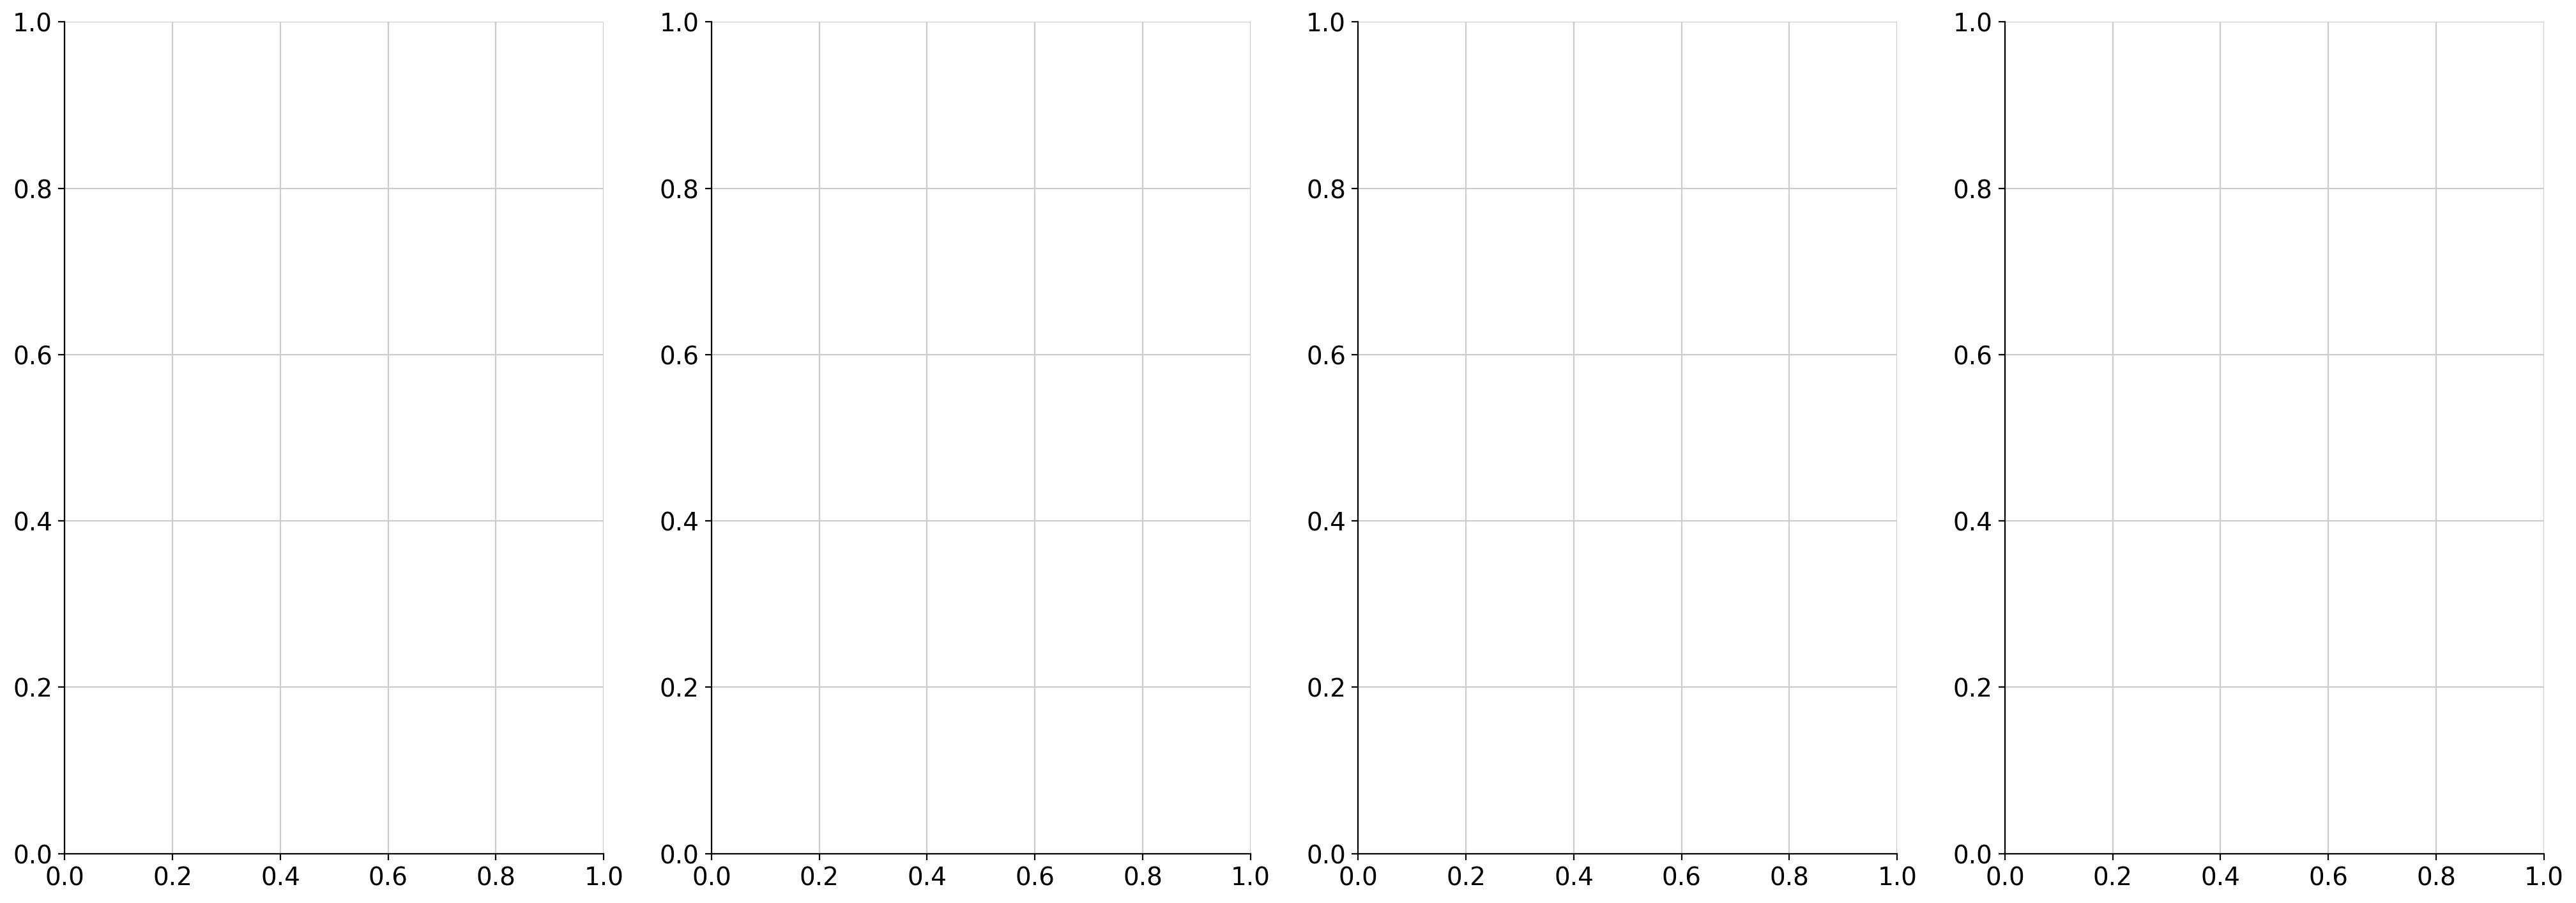

In [ ]:
fig_all_celltype_niche_heatmap(
    DS_ID, MODEL_KEYWORDS,
    celltype_key=CELLTYPE_KEY, niche_key=NICHE_KEY,
    min_cells=MIN_CELLS, metric='niche_purity',
    save_path=os.path.join(GRAPH_DIR, 'sim_recon_niche_heatmap.pdf'),
)

### 3. Difference heatmap — does sim-recon beat the plain-BANKSY baseline?

(model − BANKSY-baseline) per (cell type, niche) cell — same convention as
`scproto_spatial_comparison.ipynb`. Two things to read off this one:
- Are `+full`/`+diffusion` redder than the baseline — the actual
  single-variable ablation this notebook exists to answer.
- Is `+full` redder than `+diffusion` — the direct answer to whether the
  diffusion compression costs resolution.


Top improved (celltype, niche) pairs vs. 'scProto (BANKSY)' (min_n=5 cells):

  scProto + sim-recon/full (BANKSY):
celltype             niche                   
Smooth muscle cells  Smooth muscle structures    0.571
Pericytes            Vascular stroma             0.210
Macrophages          Macrophage islands          0.177
Smooth muscle cells  Excluded                    0.091
Fibroblasts          T cell aggregates           0.042
                     Tumor core                  0.037
Pericytes            Desmoplastic stroma         0.025
Macrophages          Desmoplastic stroma         0.017

  scProto + sim-recon/diffusion (BANKSY):
celltype             niche                   
Smooth muscle cells  Smooth muscle structures    0.523
Fibroblasts          Tumor surface               0.196
Pericytes            Vascular stroma             0.182
Smooth muscle cells  Excluded                    0.091
Fibroblasts          Tumor core                  0.053
Macrophages          Macrophage is

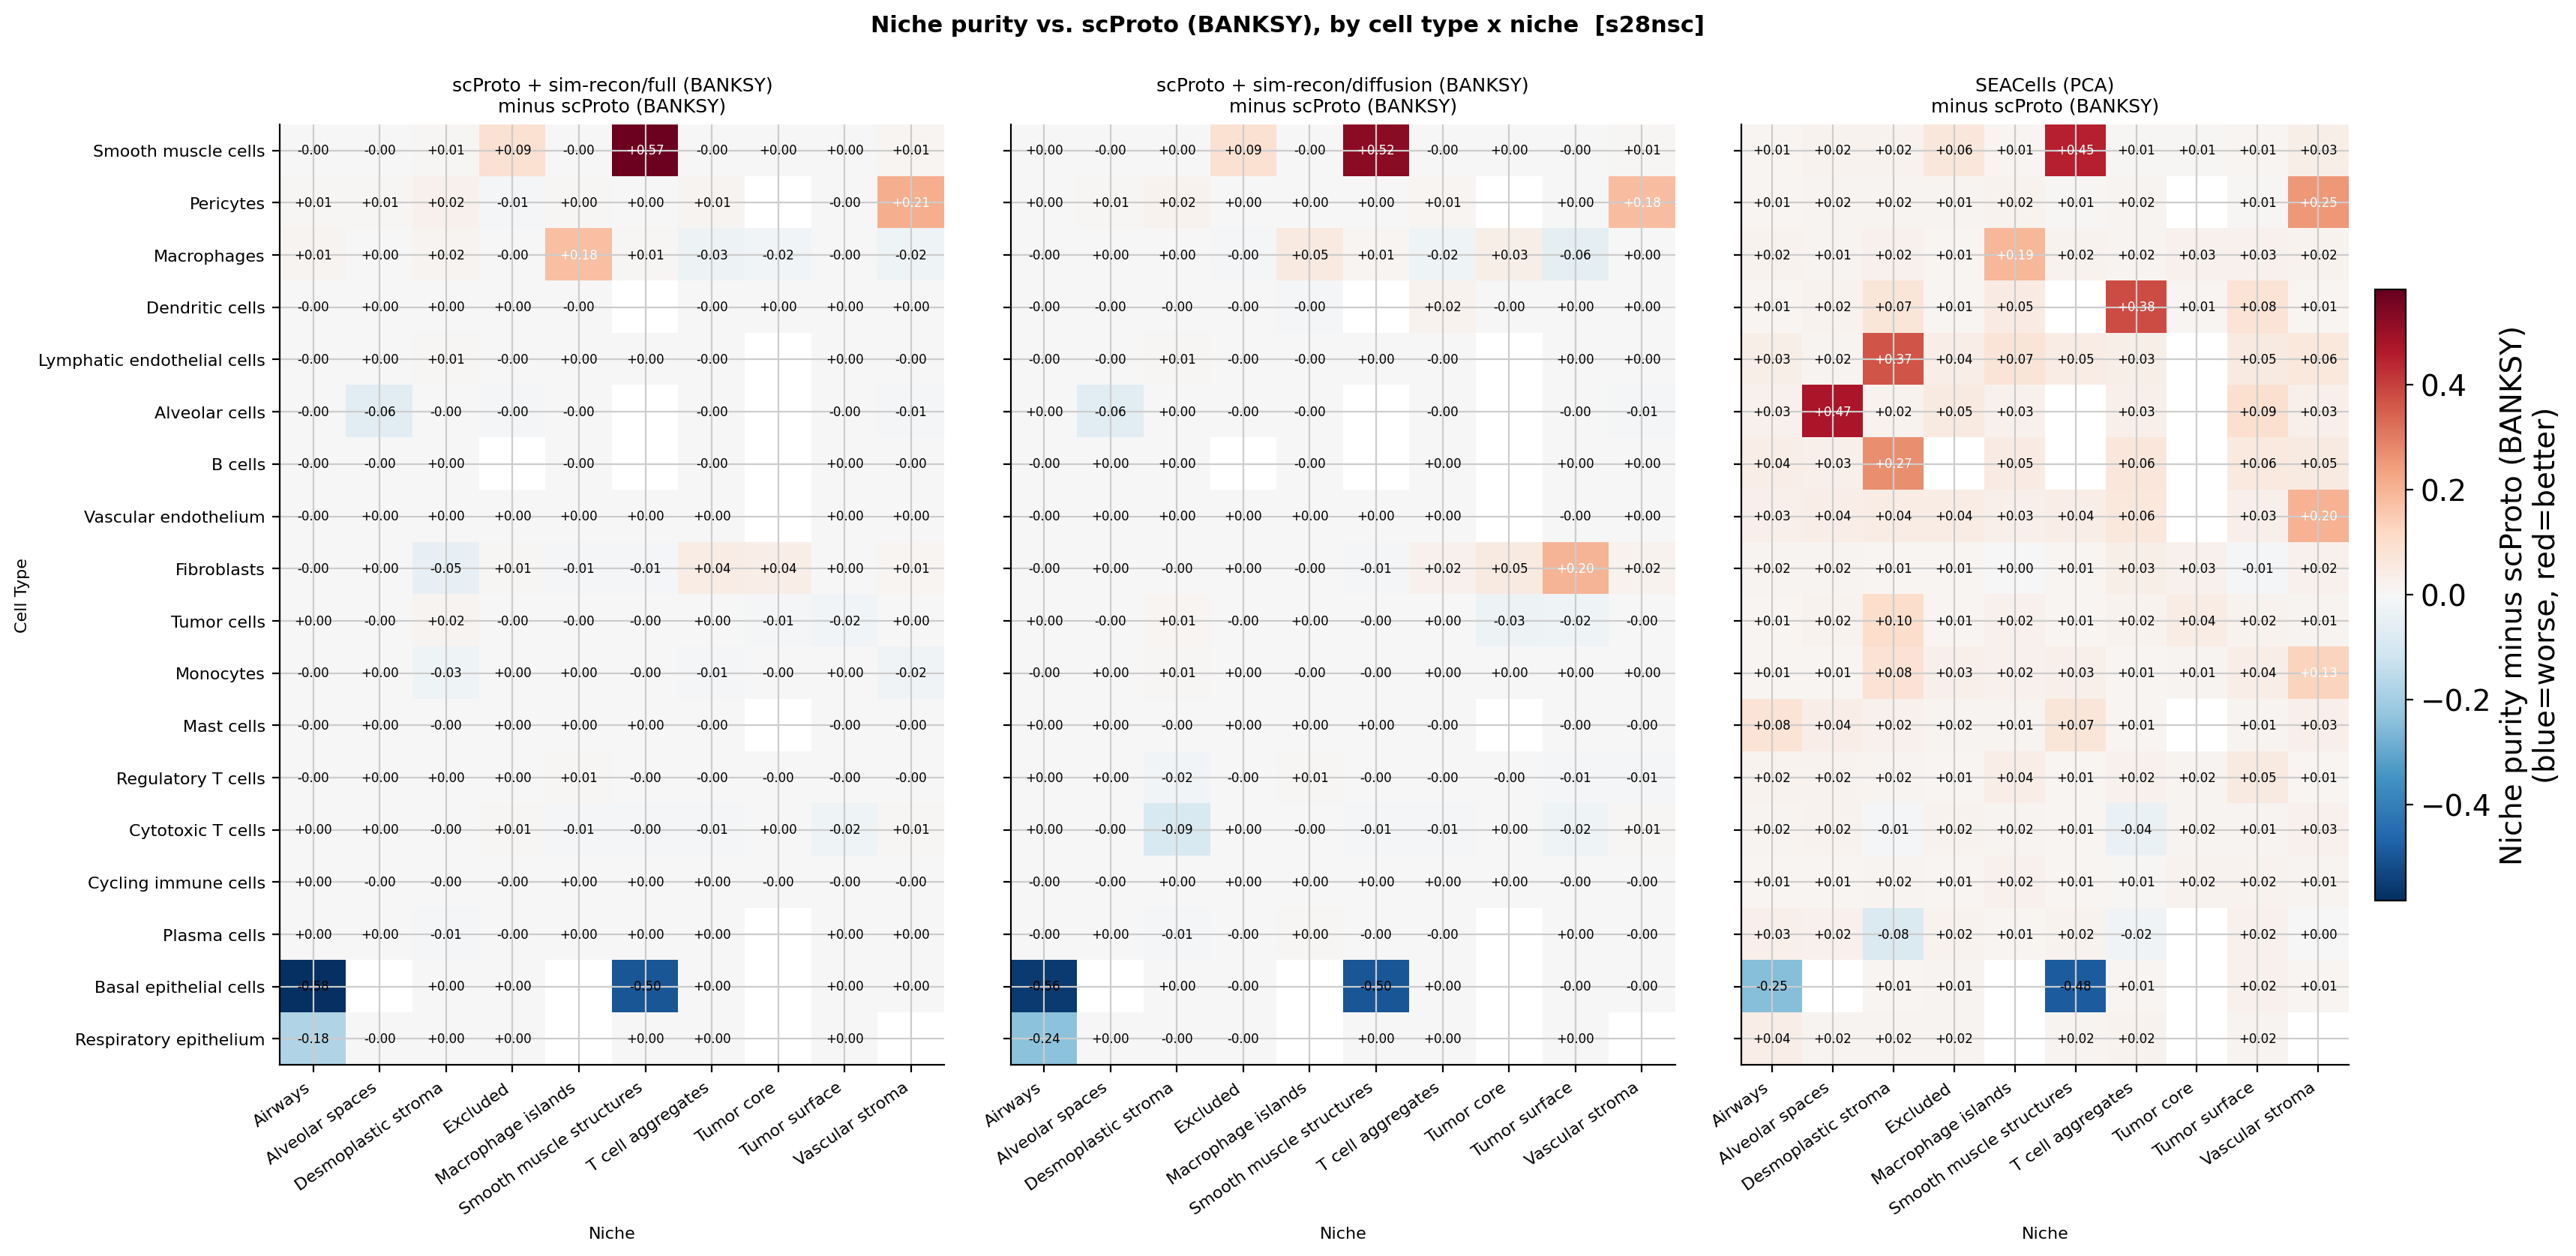

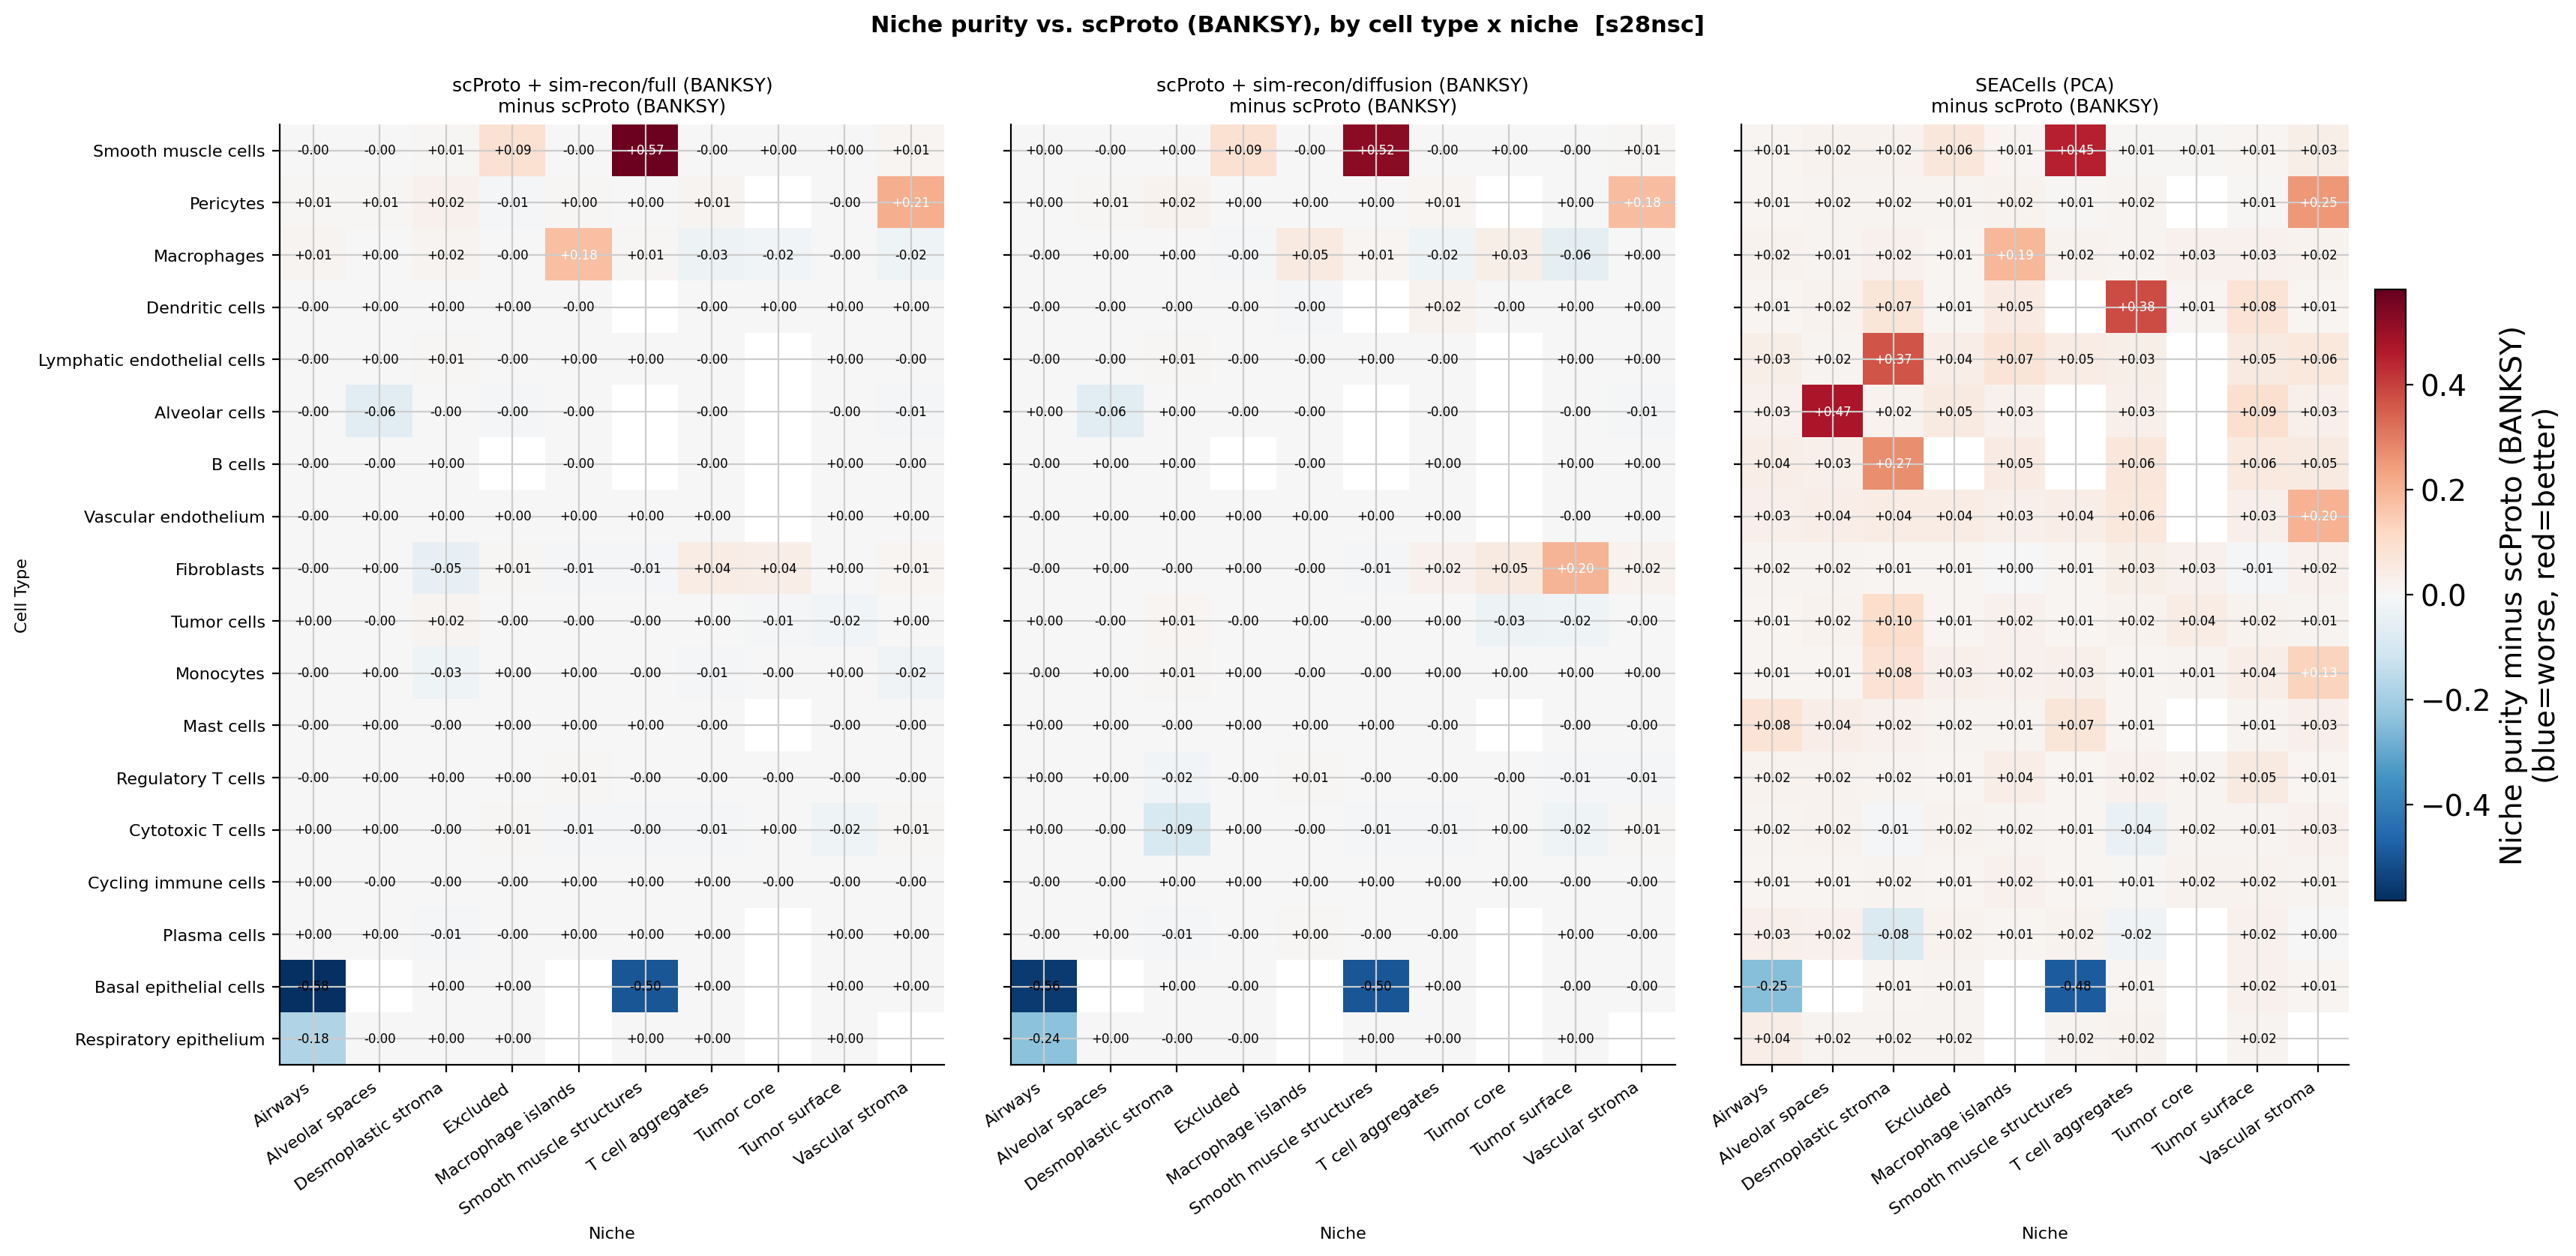

In [ ]:
fig_celltype_niche_heatmap_diff(
    DS_ID, MODEL_KEYWORDS, reference=model_names['banksy0.5'],
    celltype_key=CELLTYPE_KEY, niche_key=NICHE_KEY,
    min_cells=MIN_CELLS, metric='niche_purity', min_n=5,
    save_path=os.path.join(GRAPH_DIR, 'sim_recon_niche_diff_heatmap.pdf'),
)

### 4. Trade-off — cell-type purity vs. niche purity, per model

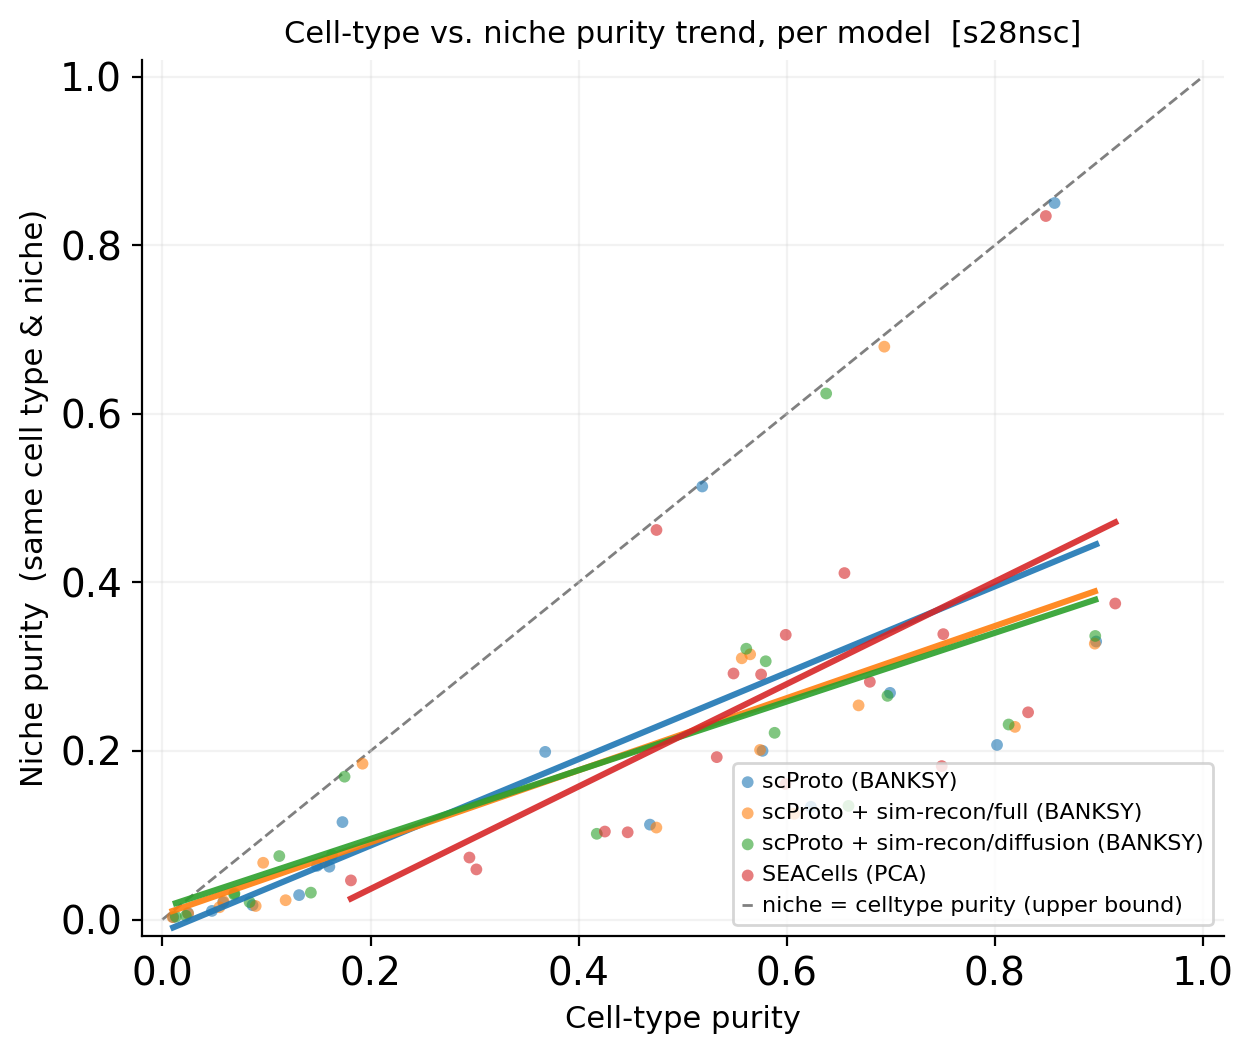

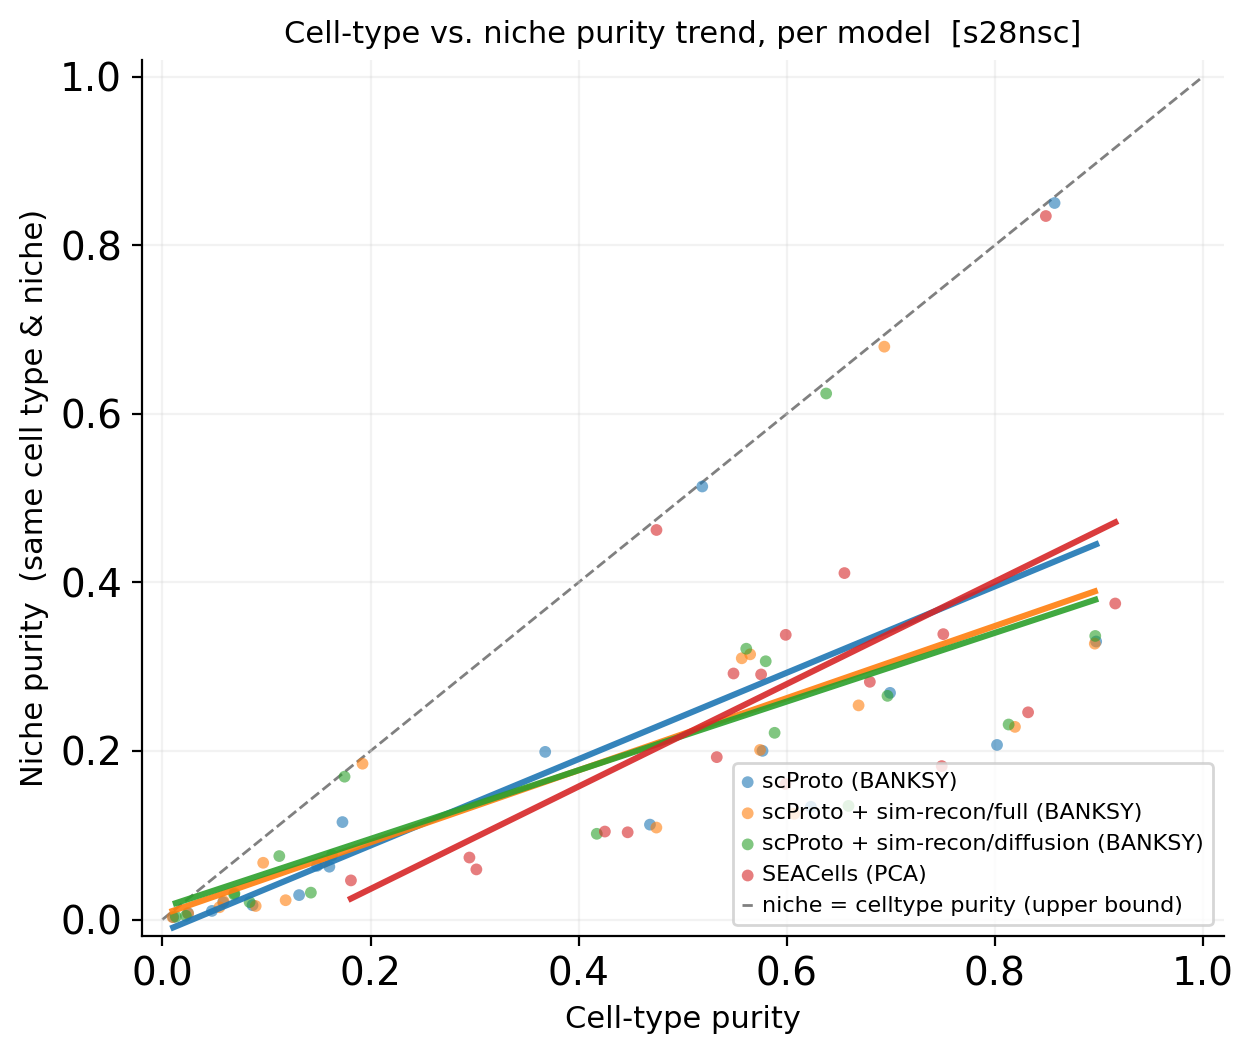

In [ ]:
fig_celltype_niche_tradeoff(
    DS_ID, MODEL_KEYWORDS,
    celltype_key=CELLTYPE_KEY, niche_key=NICHE_KEY,
    min_cells=MIN_CELLS,
    save_path=os.path.join(GRAPH_DIR, 'sim_recon_tradeoff.pdf'),
)

### 5. Niche purity summary table

In [ ]:
median_niche, q25_niche, q75_niche = fig_celltype_purity_table(
    DS_ID, MODEL_KEYWORDS,
    celltype_key=CELLTYPE_KEY, niche_key=NICHE_KEY,
    min_cells=MIN_CELLS, metric='niche_purity',
)
format_purity_table(median_niche, q25_niche, q75_niche)

celltype,Alveolar cells,B cells,Basal epithelial cells,Cycling immune cells,Cytotoxic T cells,Dendritic cells,Fibroblasts,Lymphatic endothelial cells,Macrophages,Mast cells,Monocytes,Pericytes,Plasma cells,Regulatory T cells,Respiratory epithelium,Smooth muscle cells,Tumor cells,Vascular endothelium
scProto (BANKSY),"0.17 [0.01, 0.17]","0.00 [0.00, 0.00]","0.50 [0.11, 1.00]","0.01 [0.00, 0.01]","0.05 [0.02, 0.20]","0.01 [0.00, 0.05]","0.18 [0.06, 0.37]","0.02 [0.00, 0.13]","0.12 [0.05, 0.16]","0.00 [0.00, 0.01]","0.02 [0.01, 0.05]","0.32 [0.01, 0.32]","0.13 [0.02, 0.53]","0.02 [0.00, 0.03]","0.87 [0.87, 0.87]","0.09 [0.02, 0.13]","0.36 [0.26, 0.48]","0.08 [0.02, 0.41]"
scProto + sim-recon/full (BANKSY),"0.11 [0.01, 0.11]","0.00 [0.00, 0.00]","0.16 [0.06, 0.16]","0.01 [0.00, 0.01]","0.06 [0.02, 0.20]","0.01 [0.00, 0.04]","0.25 [0.06, 0.32]","0.02 [0.00, 0.14]","0.08 [0.04, 0.16]","0.00 [0.00, 0.01]","0.02 [0.01, 0.04]","0.53 [0.02, 0.53]","0.13 [0.03, 0.52]","0.01 [0.00, 0.03]","0.69 [0.69, 0.69]","0.11 [0.01, 0.66]","0.35 [0.23, 0.46]","0.08 [0.02, 0.41]"
scProto + sim-recon/diffusion (BANKSY),"0.11 [0.00, 0.11]","0.00 [0.00, 0.01]","0.19 [0.19, 0.19]","0.01 [0.00, 0.02]","0.07 [0.03, 0.14]","0.01 [0.00, 0.06]","0.16 [0.06, 0.46]","0.02 [0.00, 0.14]","0.11 [0.04, 0.19]","0.00 [0.00, 0.01]","0.02 [0.01, 0.05]","0.50 [0.01, 0.50]","0.13 [0.02, 0.52]","0.01 [0.00, 0.02]","0.63 [0.63, 0.63]","0.11 [0.01, 0.61]","0.35 [0.24, 0.45]","0.09 [0.03, 0.41]"
SEACells (PCA),"0.55 [0.04, 0.71]","0.05 [0.01, 0.25]","0.44 [0.07, 0.87]","0.03 [0.01, 0.06]","0.11 [0.04, 0.27]","0.10 [0.02, 0.42]","0.20 [0.08, 0.38]","0.16 [0.04, 0.54]","0.14 [0.06, 0.25]","0.03 [0.01, 0.07]","0.06 [0.02, 0.22]","0.25 [0.04, 0.67]","0.22 [0.07, 0.48]","0.04 [0.02, 0.10]","0.91 [0.84, 0.96]","0.13 [0.03, 0.54]","0.42 [0.22, 0.54]","0.24 [0.07, 0.62]"


In [ ]:
median_niche.round(3).style.background_gradient(cmap='YlOrRd', vmin=0, vmax=1)

celltype,Alveolar cells,B cells,Basal epithelial cells,Cycling immune cells,Cytotoxic T cells,Dendritic cells,Fibroblasts,Lymphatic endothelial cells,Macrophages,Mast cells,Monocytes,Pericytes,Plasma cells,Regulatory T cells,Respiratory epithelium,Smooth muscle cells,Tumor cells,Vascular endothelium
scProto (BANKSY),0.169000,0.002000,0.500000,0.007000,0.051000,0.011000,0.180000,0.025000,0.122000,0.003000,0.017000,0.323000,0.132000,0.018000,0.871000,0.086000,0.359000,0.084000
scProto + sim-recon/full (BANKSY),0.106000,0.002000,0.165000,0.008000,0.055000,0.010000,0.246000,0.023000,0.084000,0.004000,0.023000,0.532000,0.134000,0.013000,0.694000,0.114000,0.352000,0.085000
scProto + sim-recon/diffusion (BANKSY),0.109000,0.002000,0.191000,0.007000,0.070000,0.011000,0.156000,0.025000,0.106000,0.003000,0.020000,0.504000,0.130000,0.011000,0.633000,0.114000,0.352000,0.086000
SEACells (PCA),0.548000,0.049000,0.439000,0.025000,0.110000,0.102000,0.203000,0.156000,0.141000,0.029000,0.060000,0.245000,0.222000,0.045000,0.912000,0.135000,0.415000,0.238000


### 6. Distribution per cell type (violin)

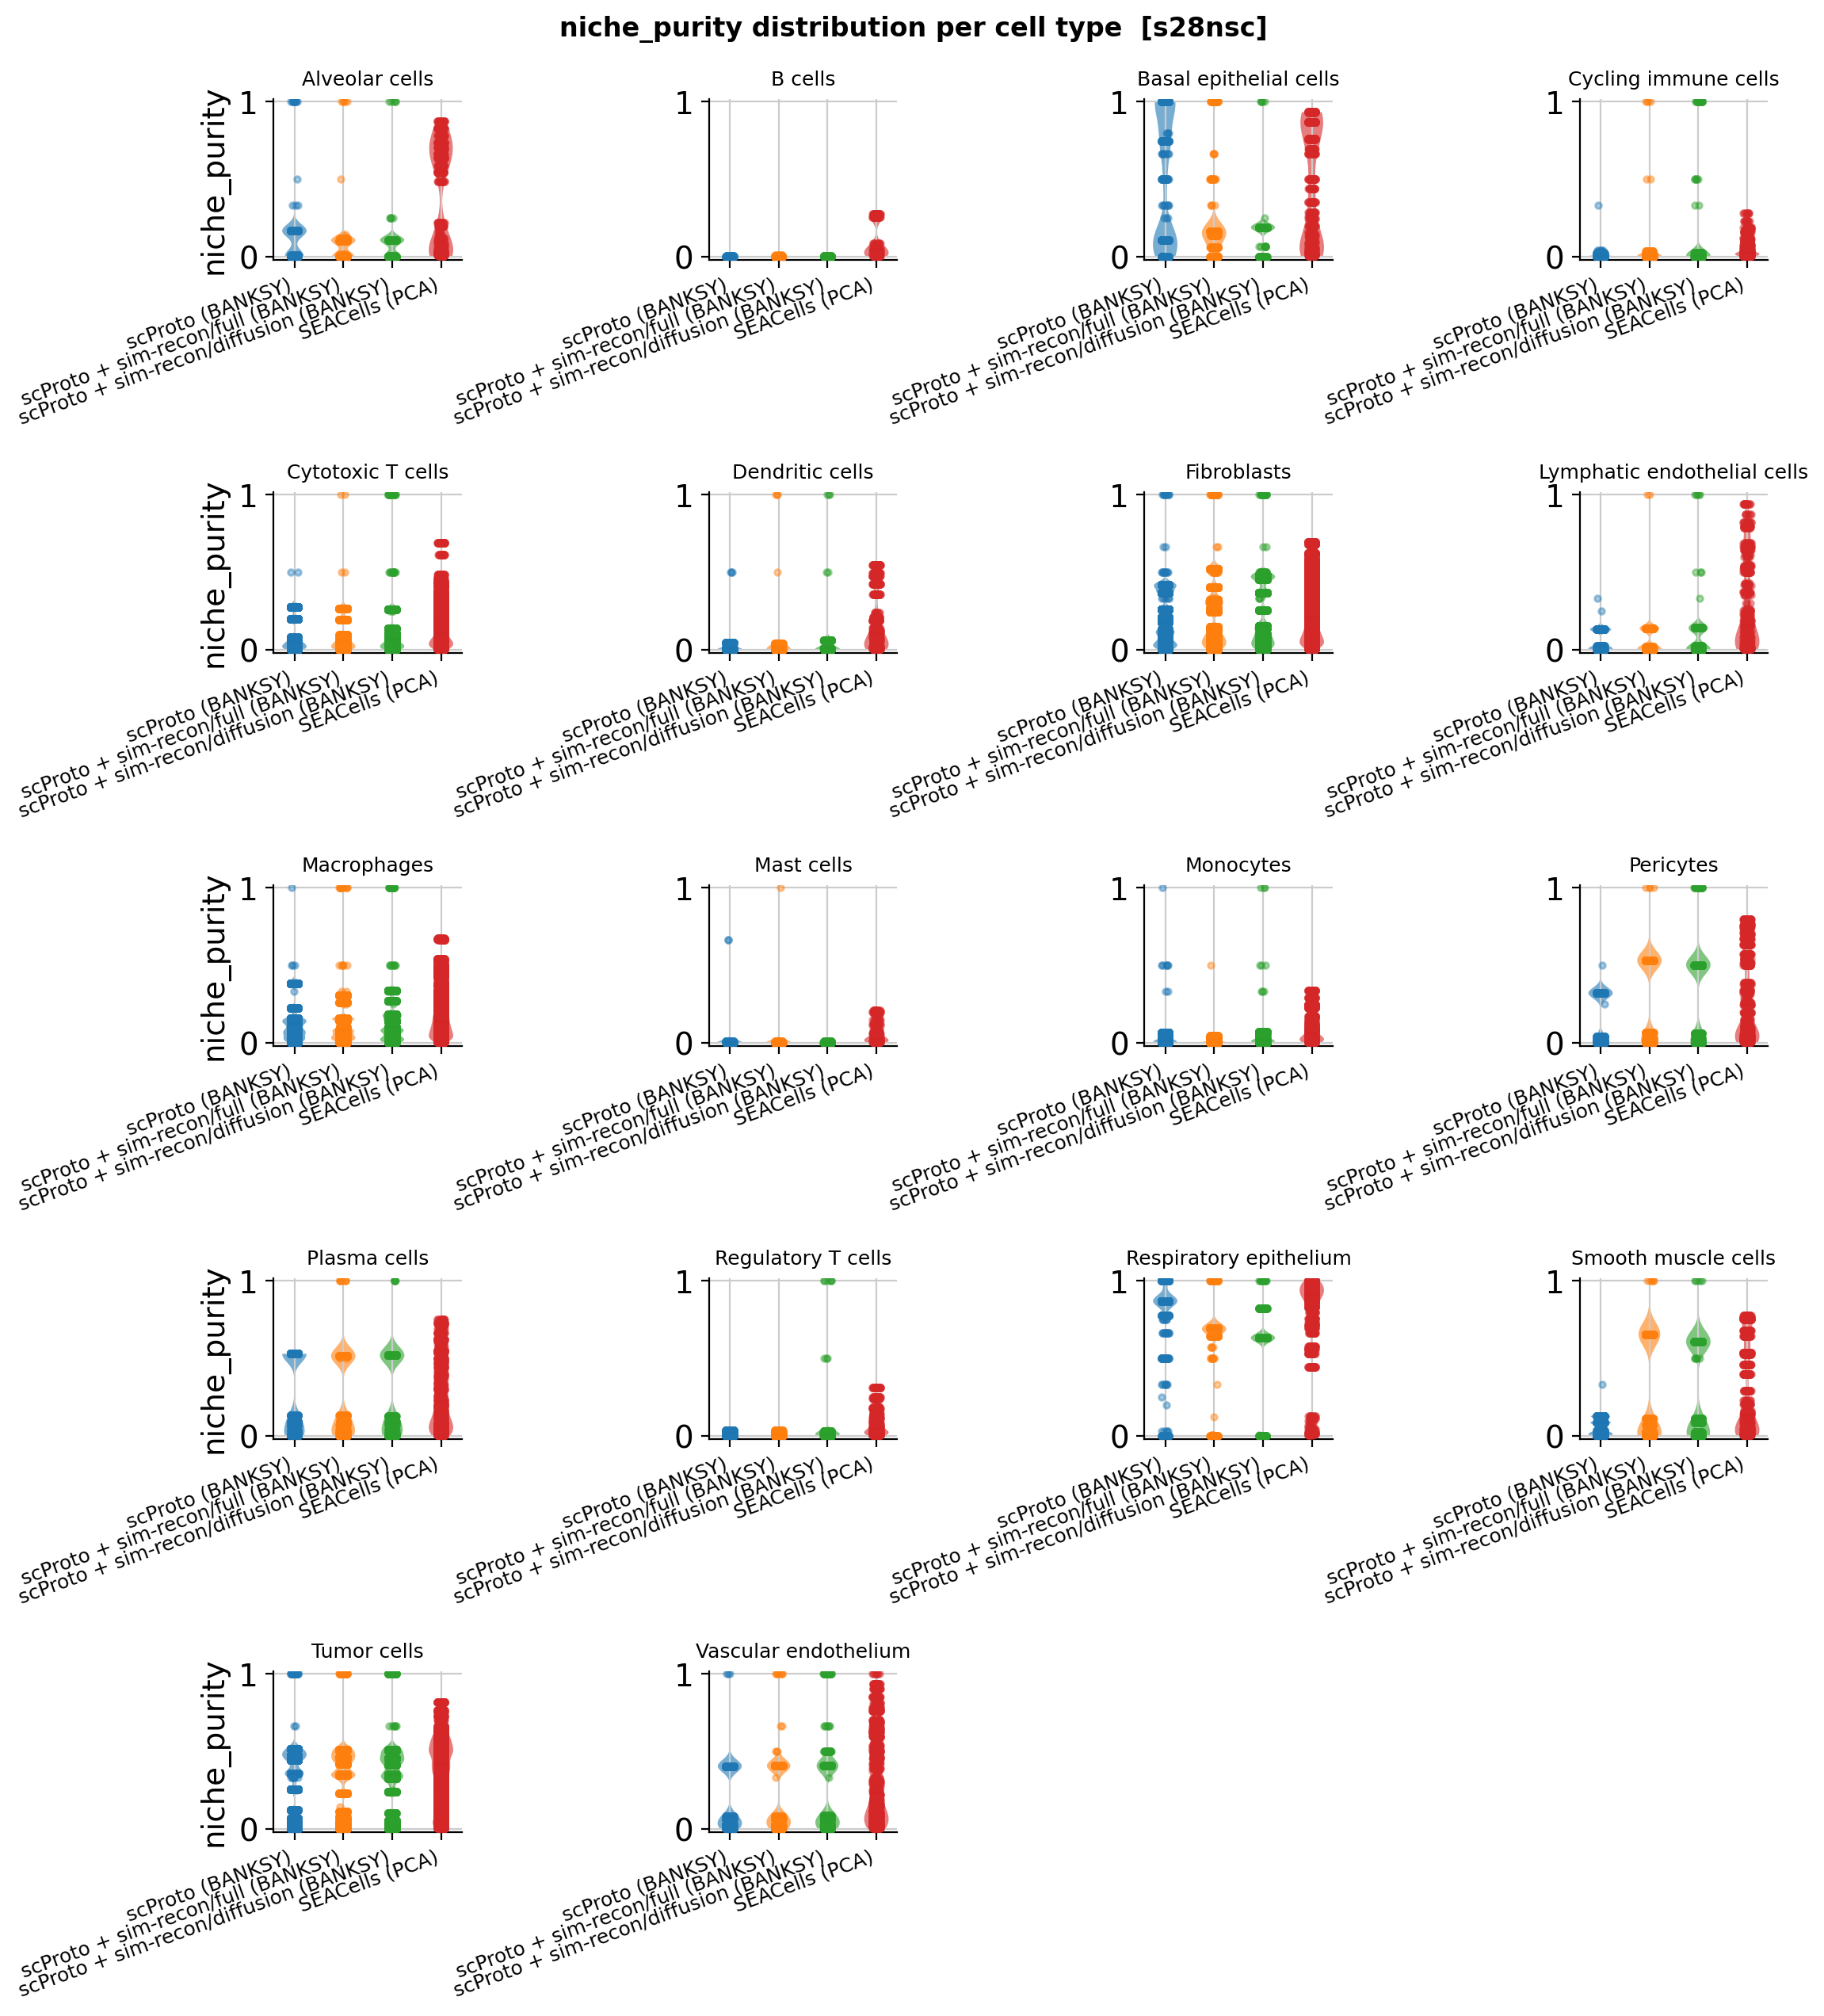

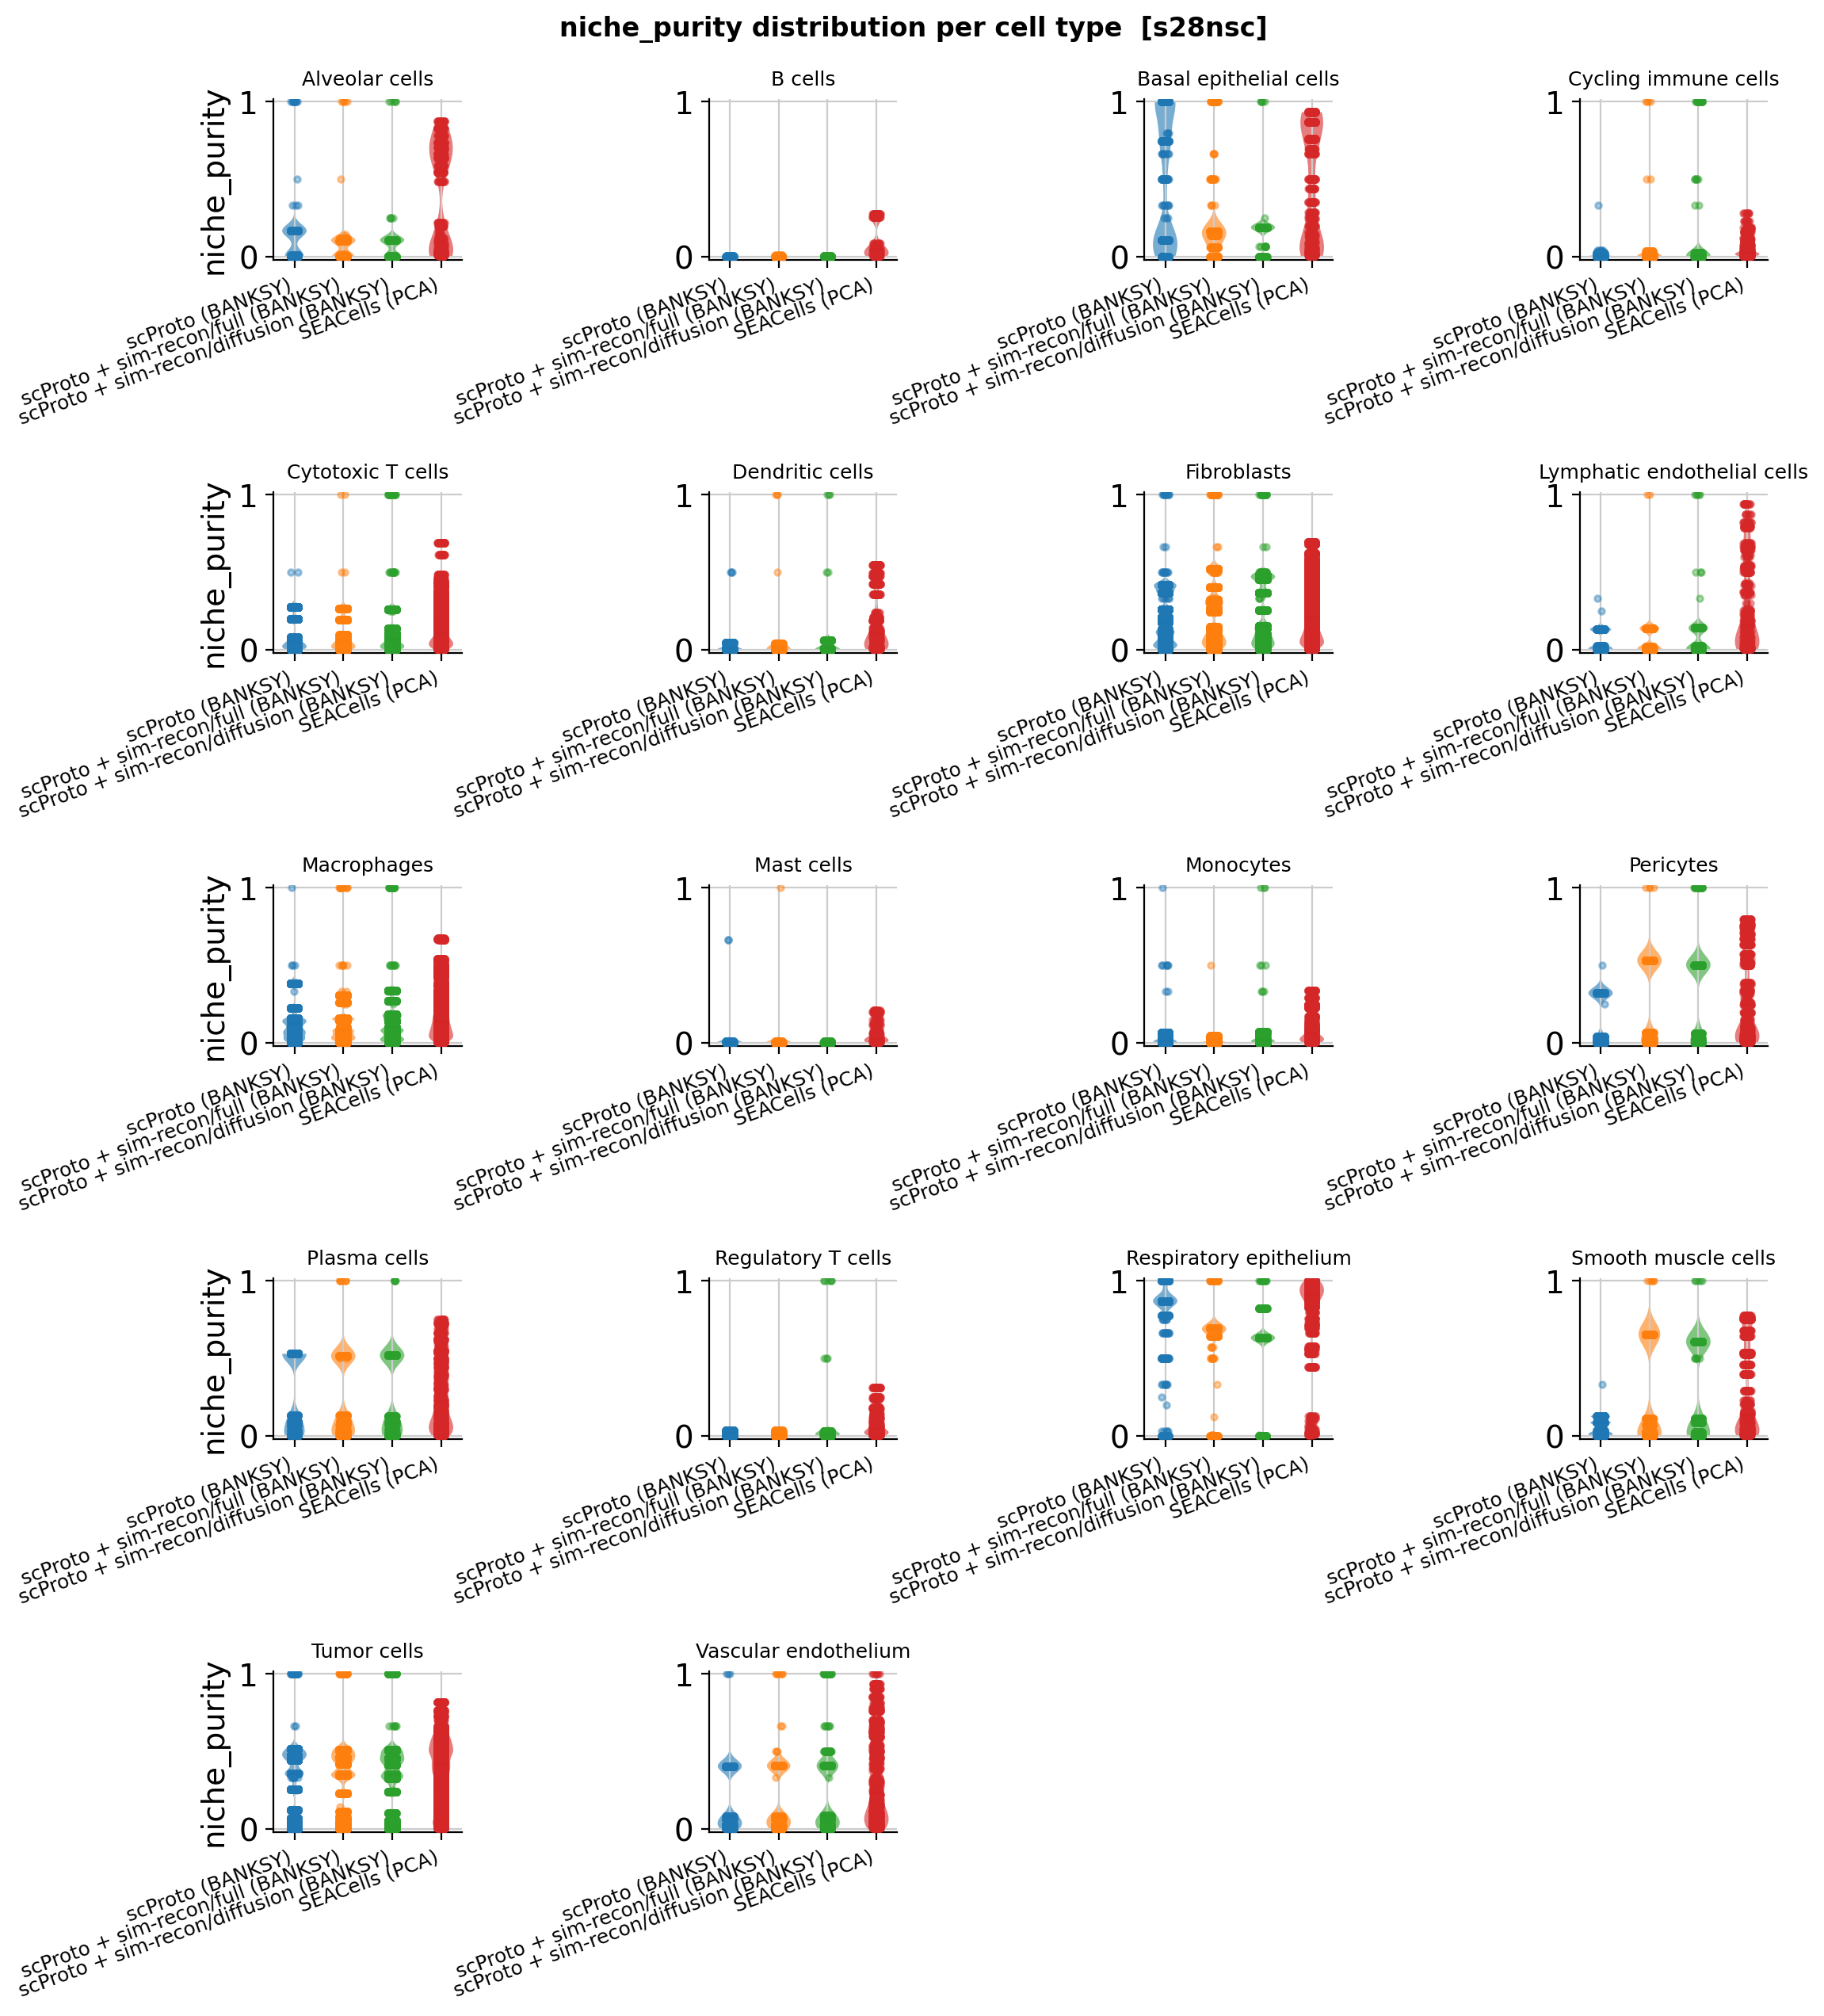

In [ ]:
fig_purity_violin(
    DS_ID, MODEL_KEYWORDS,
    celltype_key=CELLTYPE_KEY, niche_key=NICHE_KEY,
    min_cells=MIN_CELLS, metric='niche_purity',
    save_path=os.path.join(GRAPH_DIR, 'sim_recon_niche_purity_violin.pdf'),
)

## Visualize — UMAP per run

Colored by cell type and (3D) niche, prototypes overlaid.

--- banksy0.5 ---


  0%|          | 0/49 [00:00<?, ?it/s]

--- banksy0.5+full ---


  0%|          | 0/49 [00:00<?, ?it/s]

--- banksy0.5+diffusion ---


  0%|          | 0/49 [00:00<?, ?it/s]

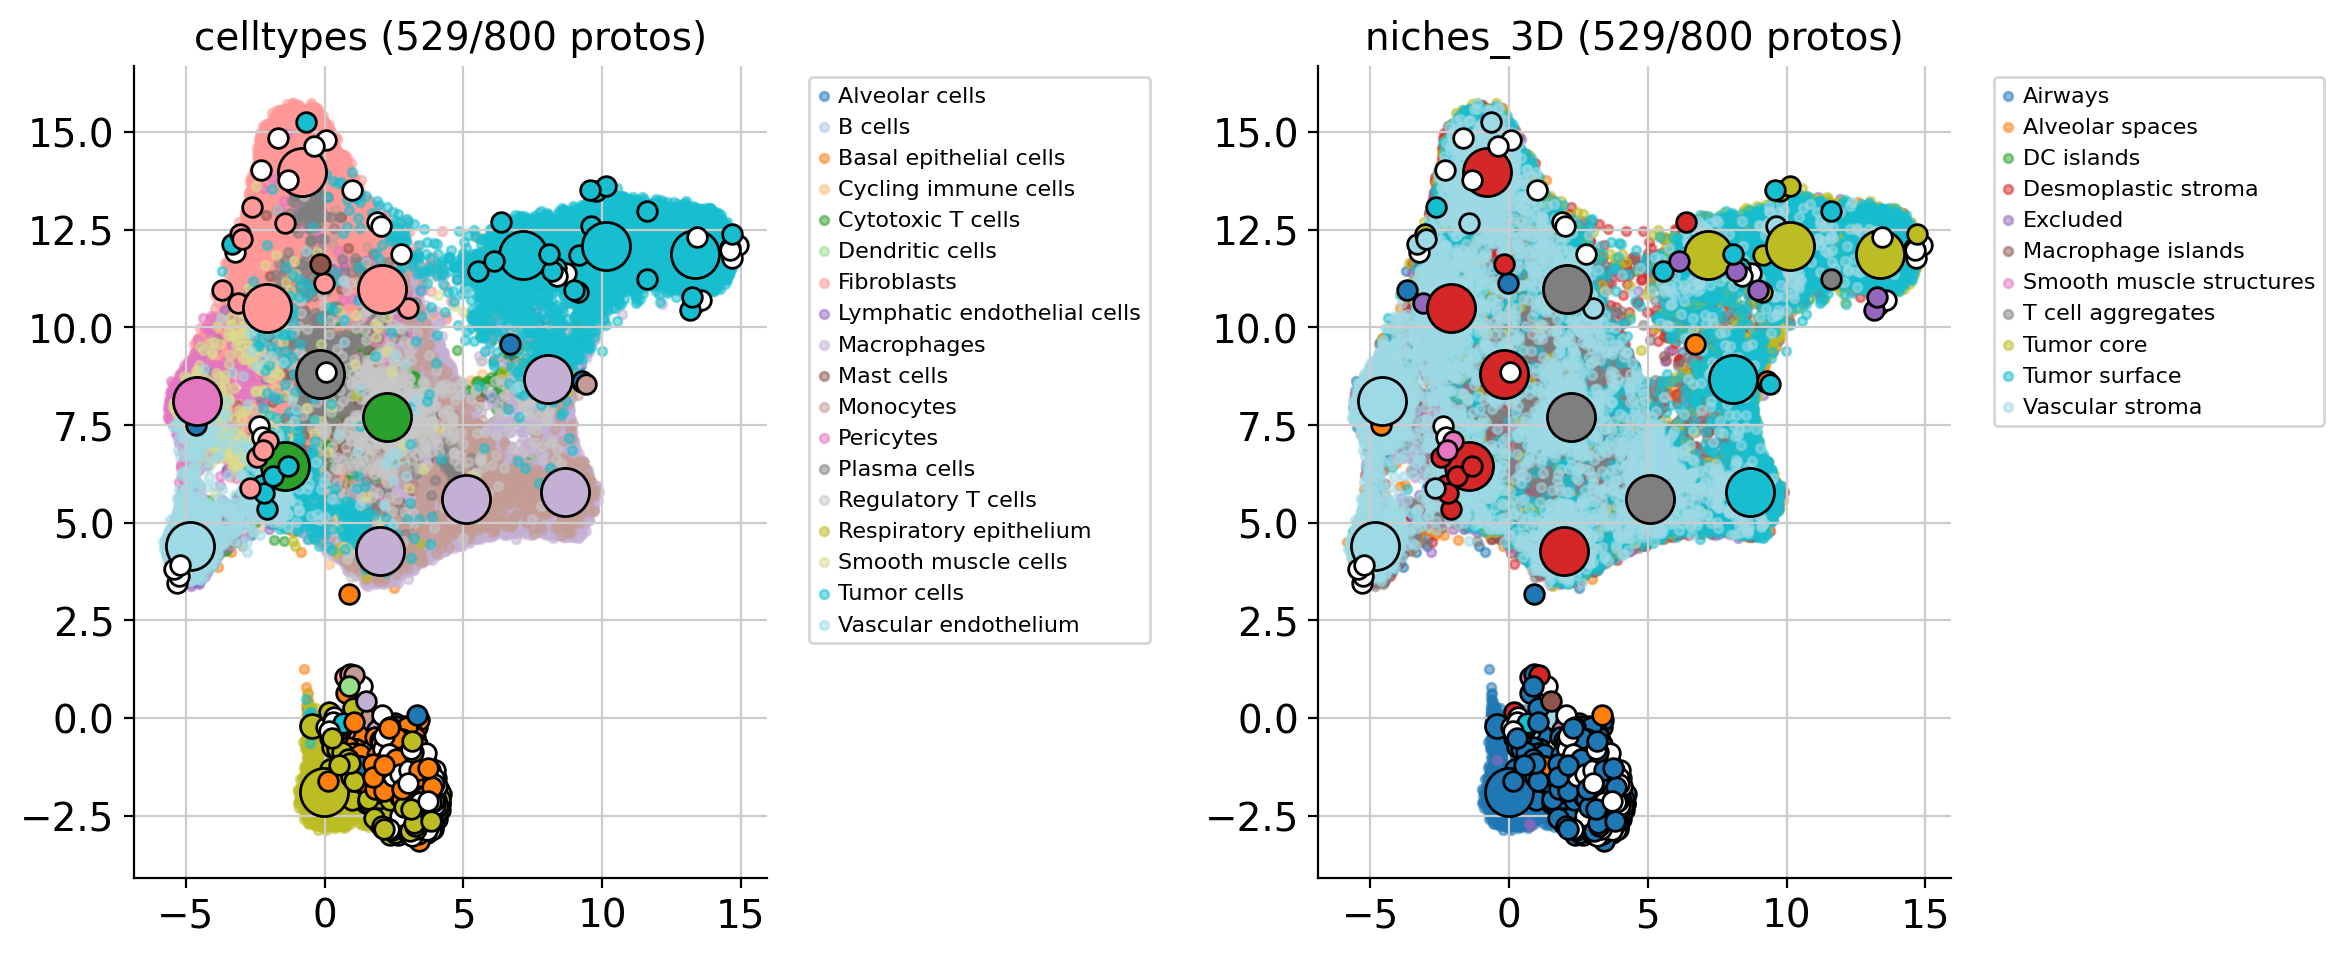

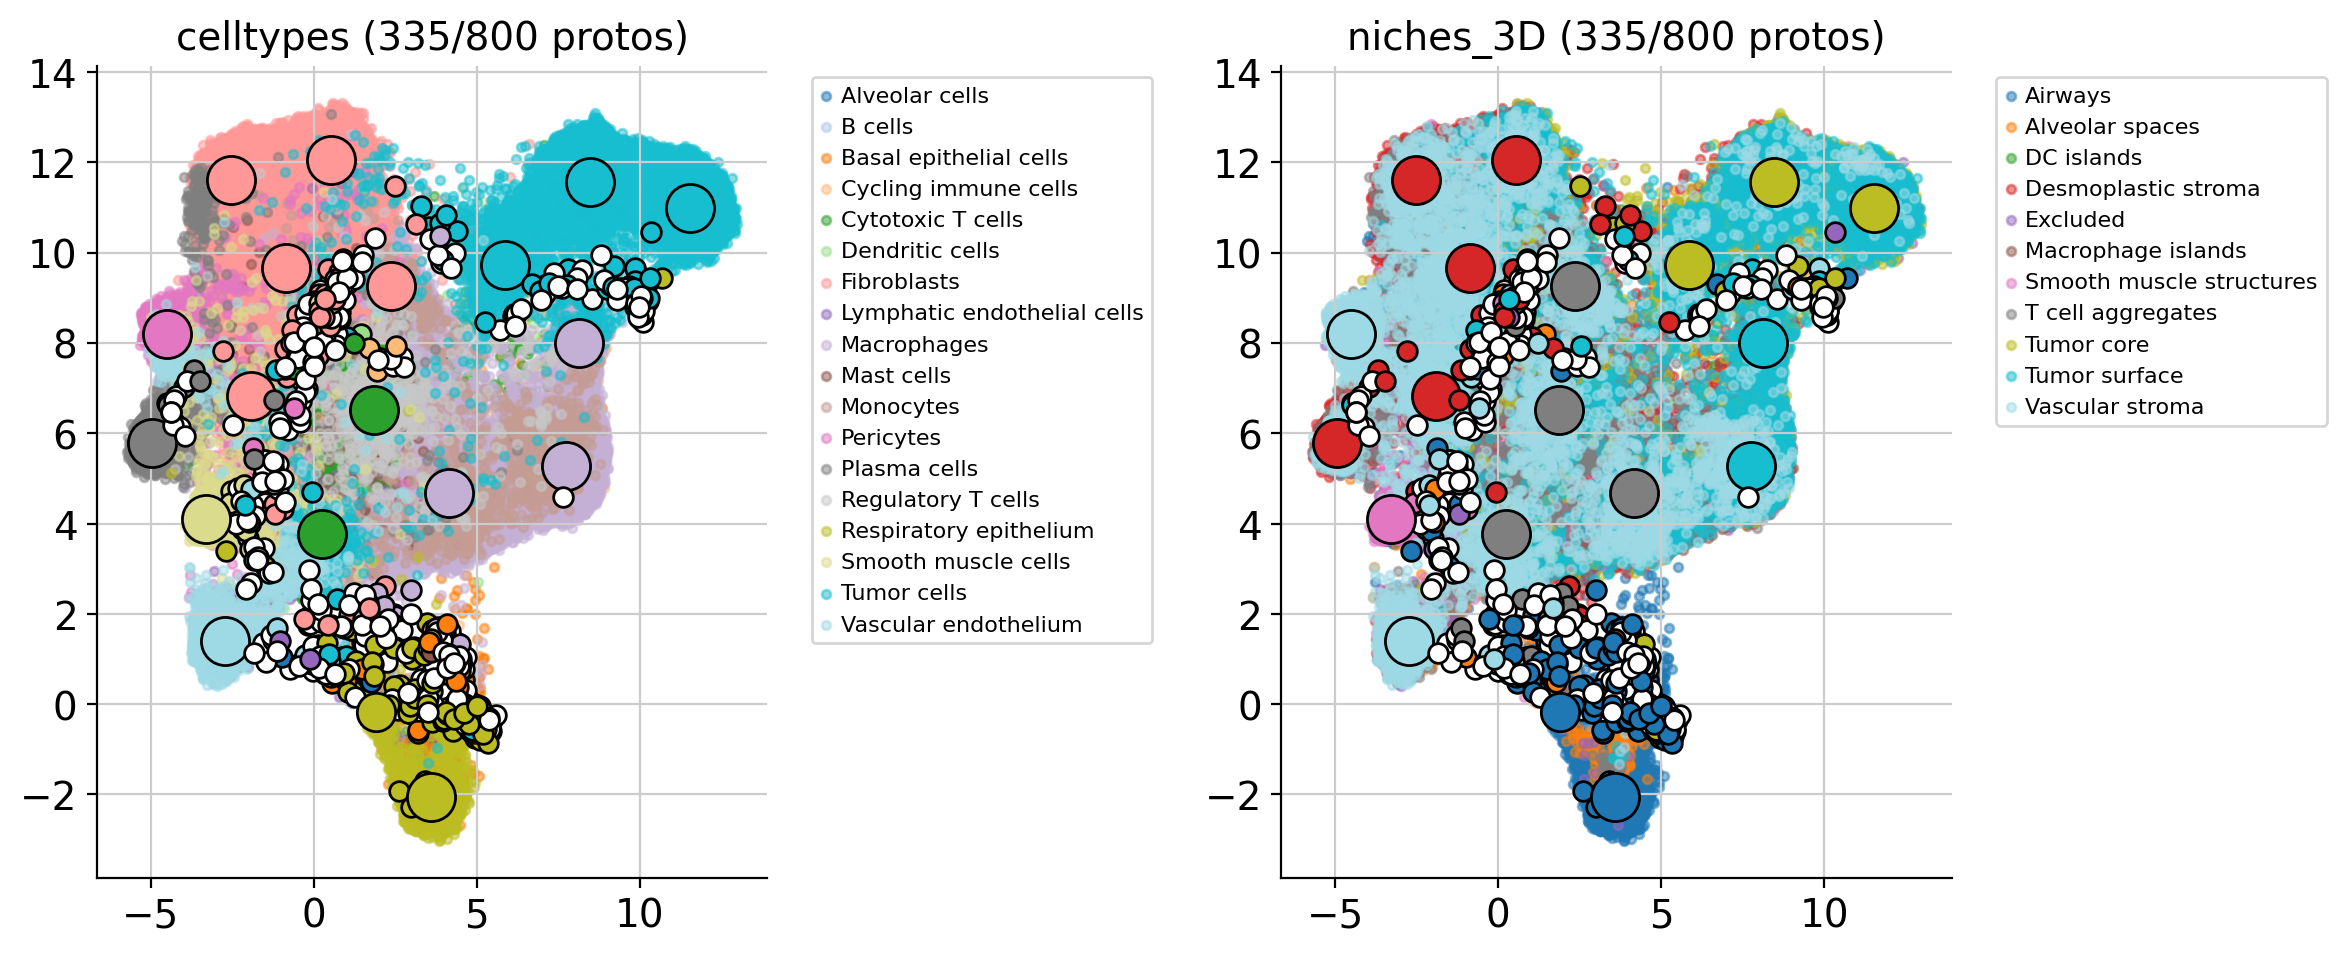

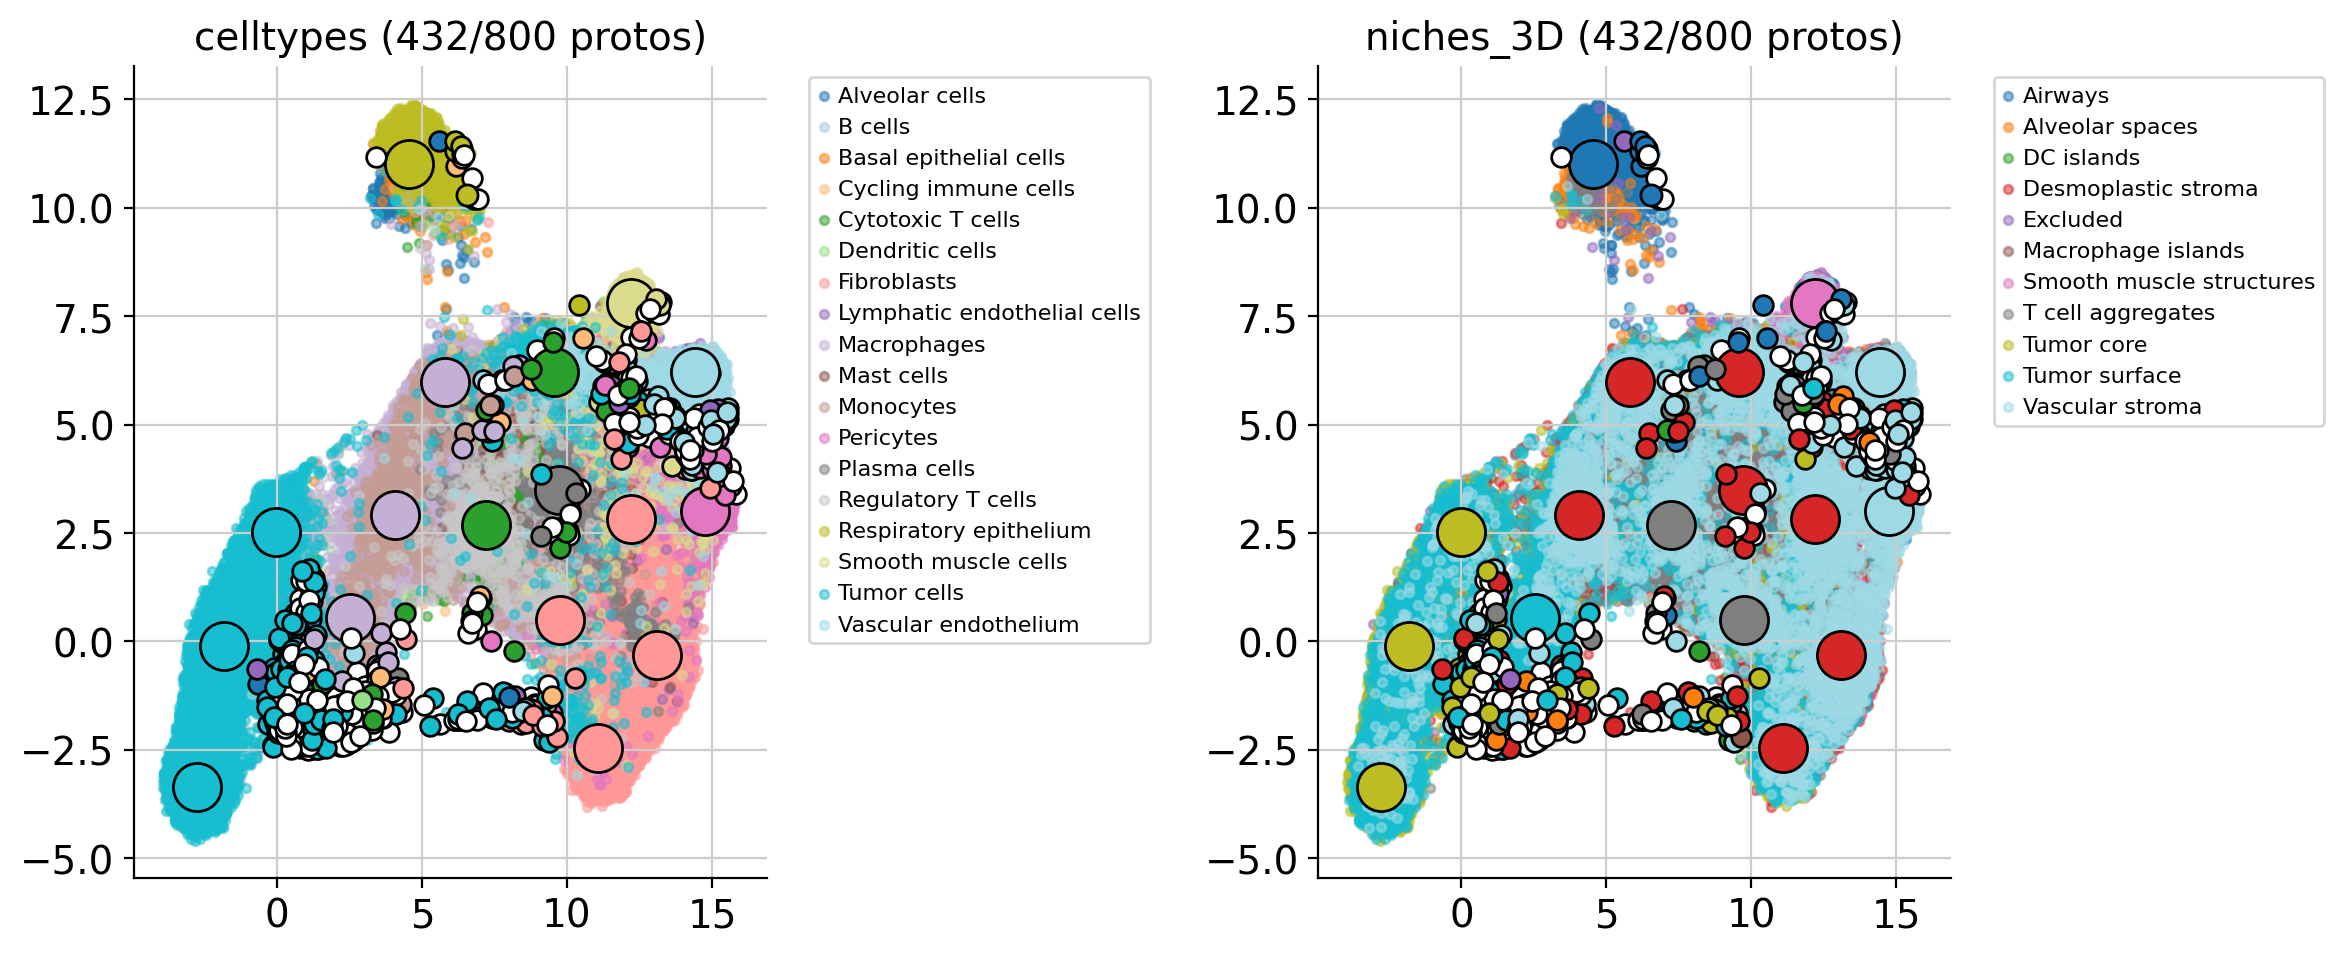

In [ ]:
for name, t in trainers.items():
    print(f'--- {name} ---')
    fig, proto_labels = t.plot_umap_simple(
        color_key=['celltypes', 'niches_3D'],
        show_proto_nums=False,
    )

## Optional — extend to the other two affinities

Only run this section once BANKSY results above show the mechanism actually
helps — it's another 6 scProto runs (arbf + mean_product, each ×3 configs).
Same `train_or_load` helper, same pattern; uncomment and run, then add the
four new labels to `MODEL_KEYWORDS` above (via `model_names[...]`) and
re-run the comparison cells to pull them in.

In [ ]:
# for aff in ['arbf', 'mean_product']:
#     train_or_load(aff, aff, load=LOAD_BASELINE)
#     train_or_load(f'{aff}+full', aff, load=LOAD_SIMRECON,
#                    extra_lambda={'lambda_sim_recon': LAMBDA_SIM_RECON, 'sim_recon_target': 'full'})
#     train_or_load(f'{aff}+diffusion', aff, load=LOAD_SIMRECON,
#                    extra_lambda={'lambda_sim_recon': LAMBDA_SIM_RECON, 'sim_recon_target': 'diffusion',
#                                   'sim_recon_n_eigs': SIM_RECON_N_EIGS})